# Rolling Windows

In [2]:
from utils import generals
import pandas as pd
import os
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import iplot
from scipy.fftpack import fft
from importlib import reload
import gc

origin = None
train = None
wws = None
hpc = None
hpt = None
esns = None
sensors = None
points = None

def check_init():
    global origin, train, wws, hpc, hpt, esns, sensors, points
    reload(generals)
    origin = generals.load_training()
    train = origin.dropna().copy() #757 righe in meno
    gc.collect() 
    esns = generals.ESN.copy()
    sensors = generals.SENSORS.tolist()

    wws = generals.get_shift('Cumulative_WWs', train)
    hpc = generals.get_shift('Cumulative_HPC_SVs', train)
    hpt = generals.get_shift('Cumulative_HPT_SVs', train)

    points = {"HPT": hpt, "HPC": hpc, "WWs": wws}

check_init()

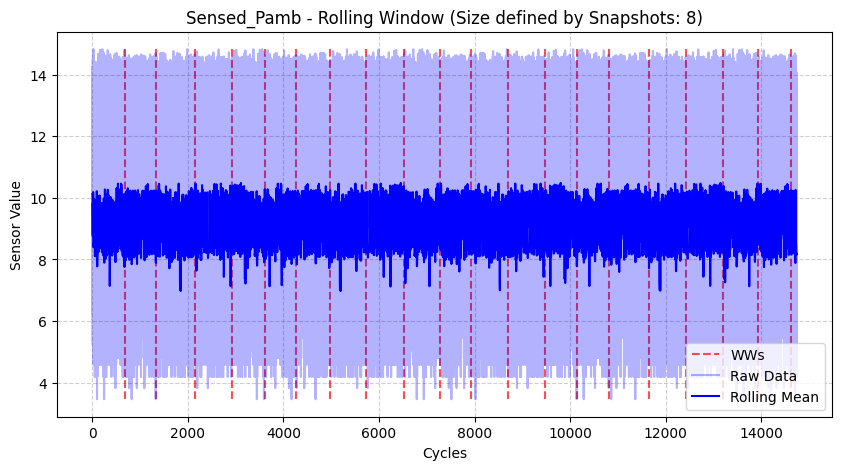

In [3]:
def __ROLLING_WINDOW():
    check_init()
    esn=101
    s = generals.SENSORS.Sensed_Pamb.value
    df = generals.filter(train, "ESN", esn, [s, 'Snapshot'])
    wsize = 8
    rolling_mean = df[s].rolling(window=wsize).mean()
    dirname = "ROLLING-WINDOW"
    # Plotting
    plt.figure(figsize=(10, 5))
    plt.vlines(wws.loc[wws['ESN'] == esn].index, ymin=df[s].min(), ymax=df[s].max(), colors='red', linestyles='dashed', label='WWs', alpha=0.7)
    plt.plot(train.loc[train['ESN'] == int(esn), [s]], label='Raw Data', color='blue', alpha=0.3)
    plt.plot(rolling_mean, label='Rolling Mean', color='blue')
    plt.title(f'{s} - Rolling Window (Size defined by Snapshots: {wsize})')
    plt.xlabel('Cycles')
    plt.ylabel('Sensor Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(f"{generals.plot_path(dirname)}/ROLLING-{s}-{wsize}-ESN{esn}")
    plt.show()

__ROLLING_WINDOW()


In [ ]:
import matplotlib.pyplot as plt
import gc  # Import Garbage Collector

# Rolling window uno per uno, snapshot per snapshot, sensore per sensore, ESN per ESN

check_init()

dirname = "ROLLING-WINDOWS"
# wsize removed here, it is defined in the loop below

esns = generals.ESN.copy()
sensors = generals.SENSORS.tolist() 
colors = cm.get_cmap('tab10', 8)

def ROLLING_WINDOWS_BY_SNAPSHOT(current_wsize):
    check_init()
    for esn in esns:
        # Correctly prepare columns for filtering the main dataframe for this ESN
        cols_for_esn_df = sensors + ['Snapshot']
        esn_df_all_data = generals.filter(train, "ESN", esn, cols_for_esn_df)

        if esn_df_all_data.empty:
            print(f"Skipping ESN {esn}: No data found.")
            continue

        for pl, p_data in points.items(): 
            path = generals.plot_path(dirname, str(esn), pl, current_wsize)

            for s in sensors:
                # Filter data specific to the current sensor and ESN
                if s not in esn_df_all_data.columns or esn_df_all_data[s].dropna().empty:
                    # print(f"Skipping ESN {esn}, Sensor {s}: No valid data.") # Optional: reduce noise
                    continue

                current_sensor_raw_df = esn_df_all_data[[s, 'Snapshot']].copy() 
                
                # Calculate rolling means for each snapshot
                rolling_means_by_snapshot = {}
                for snap_idx in range(1, 9):
                    df_snap_s = generals.filter(current_sensor_raw_df, "Snapshot", snap_idx)
                    if not df_snap_s.empty and not df_snap_s[s].dropna().empty:
                        # Logic to handle window size vs data length
                        data_len = len(df_snap_s[s].dropna())
                        if data_len >= current_wsize:
                            rolling_means_by_snapshot[snap_idx] = df_snap_s[s].rolling(window=current_wsize).mean()
                        elif data_len > 0:
                            rolling_means_by_snapshot[snap_idx] = df_snap_s[s].rolling(window=current_wsize, min_periods=1).mean()
                
                # Collect all valid rolling mean series
                valid_rolling_means_series = [
                    rm for rm in rolling_means_by_snapshot.values() 
                    if not rm.empty and not rm.isnull().all()
                ]

                if not valid_rolling_means_series:
                    continue

                # --- PLOTTING ---
                try:
                    # Determine ymin and ymax
                    ymin_plot = min(rm.min() for rm in valid_rolling_means_series)
                    ymax_plot = current_sensor_raw_df[s].max() 
                    
                    fig = plt.figure(figsize=(20, 15)) # Assign to variable
                    
                    # Plot vertical lines (Events)
                    relevant_point_indices = p_data.loc[p_data['ESN'] == esn].index
                    
                    if not relevant_point_indices.empty:
                        plot_x_min = current_sensor_raw_df.index.min()
                        plot_x_max = current_sensor_raw_df.index.max()
                        points_in_x_range = relevant_point_indices[(relevant_point_indices >= plot_x_min) & (relevant_point_indices <= plot_x_max)]

                        if not points_in_x_range.empty:
                            plt.vlines(
                                points_in_x_range,
                                ymin=ymin_plot, 
                                ymax=ymax_plot,
                                colors='red', 
                                linestyles='dashed', 
                                label=pl, 
                                alpha=0.7
                            )
                    
                    # Plot rolling means
                    for snap_idx in range(1, 9):
                        if snap_idx in rolling_means_by_snapshot:
                            rm_series = rolling_means_by_snapshot[snap_idx]
                            if not rm_series.empty and not rm_series.isnull().all():
                                plt.plot(rm_series.index, rm_series.values, label=f"Snapshot {snap_idx}", color=colors(snap_idx - 1))
                    
                    plt.title(f'ESN {esn}, Sensor {s} - Rolling Window (Size: {current_wsize}) with {pl} events')
                    plt.xlabel('Cycles')
                    plt.ylabel('Sensor Value')
                    plt.legend()
                    plt.grid(True, linestyle='--', alpha=0.6)
                    
                    final_save_path = f"{path}/{s}-{pl}-w{current_wsize}.png"
                    plt.savefig(final_save_path)
                    
                finally:
                    # STRICT CLEANUP
                    plt.close('all') # Closes all figures
                    plt.clf()        # Clears the current figure state
                    del rolling_means_by_snapshot
                    del valid_rolling_means_series
                
                # Cleanup sensor df
                del current_sensor_raw_df

        # Cleanup ESN df after processing all points/sensors for this ESN
        del esn_df_all_data
        
        # Optional: Intermediate collection if ESNs are very large
        # gc.collect() 

# --- MAIN LOOP ---
for m in [10, 25, 50, 100, 200, 500]:
    print(f"Starting processing for Window Size: {m}")
    wsize = m
    
    # Pass wsize as argument to avoid global confusion
    ROLLING_WINDOWS_BY_SNAPSHOT(wsize)
    
    # FORCE MEMORY CLEAR AFTER EACH WINDOW SIZE ITERATION
    print(f"Clearing memory after wsize {m}...")
    plt.close('all') # Double check closing plots
    gc.collect()     # Force Garbage Collection
    print(f"Memory cleared. Moving to next.")

In [ ]:
# Tutti i Sensori in una singola immagine per ESN

check_init()

dirname = "ROLLING-WINDOWS"
# wsize viene impostato nel loop finale

esns = generals.ESN.copy()
sensors = generals.SENSORS.tolist() 
colors = cm.get_cmap('tab10', 8)

def ROLLING_WINDOWS_BY_SNAPSHOT_ALL_SENSORS():
    check_init()
    
    # Assumiamo che ci siano al massimo 16 sensori per una griglia 4x4.
    # Se ce ne sono di più, verranno plottati solo i primi 16.
    max_plots = 16 

    for esn in esns:
        # Correctly prepare columns for filtering the main dataframe for this ESN
        cols_for_esn_df = sensors + ['Snapshot']
        esn_df_all_data = generals.filter(train, "ESN", esn, cols_for_esn_df)

        if esn_df_all_data.empty: 
            print(f"Skipping ESN {esn}: No data found.")
            continue

        for pl, p_data in points.items(): 
            # Create output directory for current ESN and point type
            path = generals.plot_path(dirname, str(esn), pl, wsize)
            
            # --- MODIFICA: Creazione della griglia 4x4 ---
            fig, axes = plt.subplots(4, 4, figsize=(24, 20)) # Dimensioni grandi per leggibilità
            axes_flat = axes.flatten() # Appiattiamo la matrice 4x4 in un array 1D per iterare facilmente
            
            plotted_count = 0

            for idx, s in enumerate(sensors):
                # Se superiamo i 16 sensori, interrompiamo il loop per non rompere la griglia
                if idx >= max_plots:
                    break

                ax = axes_flat[idx] # Selezioniamo l'asse corrente

                # Filter data specific to the current sensor and ESN
                if s not in esn_df_all_data.columns or esn_df_all_data[s].dropna().empty:
                    print(f"Skipping Sensor {s} for ESN {esn}: No valid data.")
                    ax.text(0.5, 0.5, 'No Data', ha='center', va='center') # Scriviamo "No Data" nel plot vuoto
                    continue

                current_sensor_raw_df = esn_df_all_data[[s, 'Snapshot']].copy()
                
                # Calculate rolling means for each snapshot
                rolling_means_by_snapshot = {}
                for snap_idx in range(1, 9):
                    df_snap_s = generals.filter(current_sensor_raw_df, "Snapshot", snap_idx)
                    if not df_snap_s.empty and not df_snap_s[s].dropna().empty:
                        if len(df_snap_s[s].dropna()) >= wsize:
                            rolling_means_by_snapshot[snap_idx] = df_snap_s[s].rolling(window=wsize).mean()
                        elif len(df_snap_s[s].dropna()) > 0:
                            rolling_means_by_snapshot[snap_idx] = df_snap_s[s].rolling(window=wsize, min_periods=1).mean()
                
                valid_rolling_means_series = [
                    rm for rm in rolling_means_by_snapshot.values() 
                    if not rm.empty and not rm.isnull().all()
                ]

                if not valid_rolling_means_series:
                    ax.text(0.5, 0.5, 'No Valid Rolling Data', ha='center', va='center')
                    continue

                # Determine ymin and ymax
                ymin_plot = min(rm.min() for rm in valid_rolling_means_series)
                ymax_plot = current_sensor_raw_df[s].max() 
                
                # --- PLOTTING SULL'ASSE 'ax' ---
                
                # Vertical lines
                relevant_point_indices = p_data.loc[p_data['ESN'] == esn].index
                if not relevant_point_indices.empty:
                    plot_x_min = current_sensor_raw_df.index.min()
                    plot_x_max = current_sensor_raw_df.index.max()
                    points_in_x_range = relevant_point_indices[(relevant_point_indices >= plot_x_min) & (relevant_point_indices <= plot_x_max)]

                    if not points_in_x_range.empty:
                        ax.vlines(
                            points_in_x_range,
                            ymin=ymin_plot, 
                            ymax=ymax_plot,
                            colors='red', 
                            linestyles='dashed', 
                            label=pl if idx == 0 else "", # Metti label solo nel primo plot per non affollare la legenda
                            alpha=0.7
                        )
                
                # Plot rolling means
                for snap_idx in range(1, 9):
                    if snap_idx in rolling_means_by_snapshot:
                        rm_series = rolling_means_by_snapshot[snap_idx]
                        if not rm_series.empty and not rm_series.isnull().all():
                            ax.plot(rm_series.index, rm_series.values, label=f"Snap {snap_idx}", color=colors(snap_idx - 1))
                
                ax.set_title(f'Sensor: {s}') # Titolo del singolo subplot
                ax.grid(True, linestyle='--', alpha=0.6)
                
                # Gestione legenda per ogni subplot o ridotta
                # ax.legend(fontsize='x-small') 
                
                plotted_count += 1

            # --- PULIZIA E SALVATAGGIO ---
            
            # Nascondi gli assi vuoti (se sensors < 16)
            for j in range(len(sensors), max_plots):
                axes_flat[j].axis('off')

            # Titolo generale dell'immagine
            fig.suptitle(f'ESN {esn} - Rolling Window (Size: {wsize}) - Event: {pl}', fontsize=16)
            
            # Aggiusta il layout per non sovrapporre i titoli
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
            
            # Salva una sola immagine per ESN
            final_save_path = f"{path}/ALL_SENSORS_ESN_{esn}_{pl}_w{wsize}.png"
            plt.savefig(final_save_path)
            plt.close(fig) # Importante: chiude la figura per liberare memoria
            print(f"Saved grid plot to {final_save_path}")

# Esecuzione del loop sulle window sizes
for m in [10, 25, 50, 100, 200, 500]:
    wsize = m
    print(f"Processing window size: {wsize}")
    ROLLING_WINDOWS_BY_SNAPSHOT_ALL_SENSORS()

In [ ]:
# reload(globals)

# points = {"HPT": hpt, "HPC": hpc, "WWs": wws}
# dirname = "ROLLING-WINDOWS"
# wsize = 200 
# esns = globals.ESN.copy()
# sensors = globals.SENSORS.tolist() 

# n_rows = len(esns)
# n_cols = len(sensors)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharex='col')


# for i, esn in enumerate(esns):
#     for j, s in enumerate(sensors):
#         ax = axes[i, j]
#         df = globals.filter(train, "ESN", esn, [s, 'Snapshot'])
#         rolling_mean = df[s].rolling(window=wsize).mean()
#         ax.plot(df.index, df[s].values, label='Raw Data', color='blue', alpha=0.3)
#         ax.plot(df.index, rolling_mean, label=f'Rolling Mean (w={wsize})', color='blue', linewidth=1.5)
#         point_colors = ['red', 'orange', 'green', 'purple']
#         for p_idx, (plabel, p_data) in enumerate(points.items()):
#             current_points = p_data.loc[p_data['ESN'] == esn]
#             if not current_points.empty:
#                 color = point_colors[p_idx % len(point_colors)]
#                 ax.vlines(
#                     x=current_points.index, 
#                     ymin=df[s].min(), 
#                     ymax=df[s].max(), 
#                     colors=color, 
#                     linestyles='dashed', 
#                     label=plabel, 
#                     alpha=0.8
#                 )
        
#         ax.grid(True, linestyle='--', alpha=0.6)
        
#         if i == 0:
#             ax.set_title(f'{s}', fontsize=12, fontweight='bold')
#         if j == 0:
#             ax.set_ylabel(f'ESN {esn}\nValue', fontsize=10, fontweight='bold')
#         if i == n_rows - 1:
#             ax.set_xlabel('Cycles')

#     save_path = globals.plot_path(dirname, "ALL_ESNS", esn) 

# handles, labels = axes[0, 0].get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# fig.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1, 1))
# plt.tight_layout()
# plt.savefig(save_path)

In [ ]:
import matplotlib.pyplot as plt
import os

# It's generally better to pass data via function arguments rather than using a global module.
# However, to match your structure, we'll assume 'globals' holds the necessary data.
# reload(globals) # This is not standard practice and can lead to unexpected behavior.

# --- Configuration & Data Loading ---
# Assumes these variables are loaded from your 'globals' module or are defined.
# esns = globals.ESN.copy()
# sensors = globals.SENSORS.tolist()
# train = globals.train
# hpt = ...
# hpc = ...
# wws = ...

points = {"HPT": hpt, "HPC": hpc, "WWs": wws}
dirname = "ROLLING-WINDOWS"
wsize = 200
point_colors = ['red', 'orange', 'green', 'purple']

# Create the main directory for plots if it doesn't exist
os.makedirs(dirname, exist_ok=True)

# --- Main Plotting Loop ---

# Loop through each unique ESN to create a separate plot file for it
for esn in esns:
    print(f"Generating plot for ESN: {esn}...")

    n_sensors = len(sensors)

    # Create a figure with one subplot per sensor, arranged in a single column
    fig, axes = plt.subplots(
        n_sensors, 1,
        figsize=(15, 5 * n_sensors),
        sharex=True  # Share the x-axis (Cycles) for better comparison
    )
    
    # If there's only one sensor, subplots returns a single Axes object, not an array.
    # We wrap it in a list to make the subsequent loop work consistently.
    if n_sensors == 1:
        axes = [axes]

    # Loop through each sensor to create its subplot within the current figure
    for i, s in enumerate(sensors):
        ax = axes[i]

        # Filter data for the current ESN and sensor
        df = generals.filter(train, "ESN", esn, [s, 'Snapshot'])
        # It's good practice to ensure the plotting index is set correctly.
        # If 'Snapshot' is not the index, you might need: df = df.set_index('Snapshot')

        # Calculate and plot the rolling mean
        rollm = df[s].rolling(window=wsize).mean()
        ax.plot(df.index, df[s].values, label='Raw Data', color='blue', alpha=0.3)
        ax.plot(df.index, rollm, label=f'Rolling Mean (w={wsize})', color='darkblue', linewidth=2)

        # Plot vertical lines for specific points (HPT, HPC, etc.)
        for p_idx, (plabel, p_data) in enumerate(points.items()):
            current_points = p_data.loc[p_data['ESN'] == esn]
            if not current_points.empty:
                color = point_colors[p_idx % len(point_colors)]
                ax.vlines(
                    x=current_points.index,
                    ymin=df[s].min(),
                    ymax=df[s].max(),
                    colors=color,
                    linestyles='dashed',
                    label=plabel,
                    alpha=0.9,
                    linewidth=2
                )

        # --- Subplot Formatting ---
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_ylabel(s, fontsize=12, fontweight='bold')
        ax.legend() # Add a legend to each subplot for clarity

    # --- Figure-level Formatting ---
    # Set a common X-axis label on the last subplot
    axes[-1].set_xlabel('Cycles', fontsize=14, fontweight='bold')

    # Create a single, unified legend for the entire figure to avoid redundancy.
    # We can grab handles and labels from any subplot.
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles)) # Removes duplicate labels
    fig.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(0.98, 0.98))

    # Add a main title to the figure
    fig.suptitle(f'Sensor Analysis for ESN {esn}', fontsize=18, fontweight='bold')

    # Adjust layout to prevent labels/titles from overlapping
    fig.tight_layout(rect=[0, 0, 0.95, 0.96])

    # Save the figure to a file
    save_path = generals.plot_path(dirname, "PER_ESN")
    plt.savefig(save_path)
    print(f"Saved plot to {save_path}")

    # Close the figure to free up memory, which is critical when looping
    plt.close(fig)

print("\nAll plots generated successfully.")


In [ ]:

points = {"HPT": hpt, "HPC": hpc, "WWs": wws}
point_colors = ['red', 'orange', 'green', 'purple']
wsizes = [10, 50, 100, 200, 500, 1000, 2000]
for window in wsizes:
    dirname = f"ROLLING-WINDOWS/PER_ESN/SIZE-{window}"

    for esn in esns:
        for s in sensors:

            df = generals.filter(train, "ESN", esn, generals.SENSORS.tolist().append("Snapshot"))

            for snap in df["Snapshot"].unique():

                df_snap = df[df["Snapshot"] == snap].copy()
                if len(df_snap) < window:
                    continue  # rolling mean would be empty

                # 🔴 CRITICAL FIX
                df_snap = df_snap.reset_index(drop=True)
                x = np.arange(len(df_snap))

                rollm = df_snap[s].rolling(
                    window=window,
                    min_periods=1
                ).mean()

                fig, ax = plt.subplots(figsize=(10, 6))

                ax.plot(
                    x,
                    df_snap[s].values,
                    label="Raw Data",
                    color="blue",
                    alpha=0.4
                )

                ax.plot(
                    x,
                    rollm.values,
                    label=f"Rolling Mean (w={window})",
                    color="darkblue",
                    linewidth=1.5
                )

                # --- Event markers ---
                for p_idx, (plabel, p_data) in enumerate(points.items()):
                    current_points = p_data[
                        (p_data["ESN"] == esn)
                    ]
                    if not current_points.empty:
                        ax.vlines(
                            x=current_points.index,
                            ymin=df_snap[s].min(),
                            ymax=df_snap[s].max(),
                            colors=point_colors[p_idx % len(point_colors)],
                            linestyles="dashed",
                            alpha=0.8,
                            label=plabel
                        )

                ax.set_title(
                    f"ESN {esn} | {s} | Snapshot {snap} | Window {window}",
                    fontsize=12,
                    fontweight="bold"
                )
                ax.set_xlabel("Cycles")
                ax.set_ylabel("Value")
                ax.grid(True, linestyle="--", alpha=0.6)
                ax.legend()

                save_path = generals.plot_path(dirname)
                plt.tight_layout()
                plt.savefig(f"{save_path}/ESN{esn}_{s}_SNAP{snap}.png")
                plt.close(fig)
k = 12

In [ ]:
len(sensors)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from importlib import reload
import os

reload(generals)

dirname = "ROLLINGW"
wsize = 200

# Define all point datasets here. 
# Add 'LPT': lpt, etc., if you have them.
points = {
    "HPT": hpt
}

# Get lists for iteration
esn_list = list(generals.ESN)
# Assuming globals.SENSORS is an iterable or list. If it's an Enum, use [s.name for s in globals.SENSORS]
sensor_list = generals.SENSORS.tolist()

n_rows = len(esn_list)
n_cols = len(sensor_list)

# Create a grid of subplots
# Adjust figsize dynamically: 6 inches per sensor (col), 4 inches per ESN (row)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharex='col')

# Ensure axes is always a 2D array for consistent indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Iterate over every ESN (Rows)
for i, esn_id in enumerate(esn_list):
    
    # Pre-filter train data for this ESN to avoid repeated filtering
    esn_train_data = train[train['ESN'] == esn_id]
    
    # Iterate over every Sensor (Columns)
    for j, sensor in enumerate(sensor_list):
        ax = axes[i, j]
        
        # Extract Sensor Data
        if sensor not in esn_train_data.columns:
            ax.text(0.5, 0.5, "Sensor Not Found", ha='center', va='center')
            continue
            
        sensor_series = esn_train_data[sensor]
        
        if sensor_series.empty:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center')
            continue

        # Calculate Rolling Mean
        rollm = sensor_series.rolling(window=wsize).mean()

        # 1. Plot Raw Data
        ax.plot(sensor_series.index, sensor_series.values, label='Raw Data', color='blue', alpha=0.3)
        
        # 2. Plot Rolling Mean
        ax.plot(sensor_series.index, rollm, label=f'Rolling Mean (w={wsize})', color='blue', linewidth=1.5)

        # 3. Iterate over every 'points' dataset and plot vertical lines
        # Define a color cycle for different point types
        point_colors = ['red', 'orange', 'green', 'purple']
        
        for p_idx, (plabel, p_data) in enumerate(points.items()):
            # Filter points for the current ESN
            # Assuming p_data index aligns with train data index (Cycles)
            current_points = p_data.loc[p_data['ESN'] == esn_id]
            
            if not current_points.empty:
                color = point_colors[p_idx % len(point_colors)]
                ax.vlines(
                    x=current_points.index, 
                    ymin=sensor_series.min(), 
                    ymax=sensor_series.max(), 
                    colors=color, 
                    linestyles='dashed', 
                    label=plabel, 
                    alpha=0.8
                )

        # Formatting
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Set Titles and Labels
        # Top row gets Sensor names
        if i == 0:
            ax.set_title(f'{sensor}', fontsize=12, fontweight='bold')
        
        # Left column gets ESN labels
        if j == 0:
            ax.set_ylabel(f'ESN {esn_id}\nValue', fontsize=10, fontweight='bold')
        
        # Bottom row gets x-axis label
        if i == n_rows - 1:
            ax.set_xlabel('Cycles')

# Add a single legend to the figure (or the first subplot) to avoid clutter
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save the combined plot
output_path = f"{generals.PLOT_PATH}/{dirname}/ALL_ESN_ALL_SENSORS_COMBINED.png"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
plt.savefig(output_path)
print(f"Saved combined plot to: {output_path}")
plt.close()


In [ ]:
reload(generals)

esn=101
dirname = "BY_SNAPSHOT"
phase = 1
p = hpt
pl = "HPT"

path = f"{generals.PLOT_PATH}/{dirname}/{esn}/"
os.makedirs(os.path.dirname(path), exist_ok=True)
for s in generals.SENSORS.iter():
    s = s
    df = generals.filter(train, "ESN", esn, [s, 'Snapshot'])

    colors = cm.viridis(np.linspace(0, 1, 8))
    plt.figure(figsize=(50, 20))
    for i in range(1,9):
        df = generals.filter(df, "Snapshot", i, [s, 'Snapshot'])
        plt.plot(df, label=f'Valore nella fase {i} ',color=colors[i-1], alpha=0.4)

    plt.vlines(p.loc[p['ESN'] == esn].index, ymin=df[s].min(), ymax=df[s].max(), colors='red', linestyles='dashed', label=pl, alpha=0.7)
    plt.title(f'valore {s} per fase')
    plt.xlabel('Cycles')
    plt.ylabel('Sensor Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show() 
    plt.savefig(f"{path}/{s}-{pl}")


In [ ]:
reload(generals)
import plotly.graph_objects as go
import os

esn = 101
dirname = "BY_SNAPSHOT"
phase = 1
p = hpt
pl = "HPT"

path = f"{generals.PLOT_PATH}/{dirname}/{esn}/"
os.makedirs(path, exist_ok=True)

# Define a discrete colorscale (replaces cm.viridis)
colors = [
    '#440154', '#482878', '#3e4989', '#31688e', 
    '#26828e', '#1f9e89', '#6ece58', '#fde725'
]

for s in generals.SENSORS.iter():
    s = s
    df = generals.filter(train, "ESN", esn, [s, 'Snapshot'])
    
    # Initialize the figure
    fig = go.Figure()

    # 1. Add the lines for each Snapshot
    for i in range(1, 9):
        df = generals.filter(df, "Snapshot", i, [s, 'Snapshot'])
        
        fig.add_trace(go.Scatter(
            x=df.index, 
            y=df[s],
            mode='lines',
            name=f'Fase {i}',
            line=dict(color=colors[i-1], width=1.5),
            opacity=0.6
        ))

    # 2. Add Vertical Lines (Vlines)
    # Finding the x-coordinates for the specific ESN
    v_points = p.loc[p['ESN'] == esn].index
    
    for vp in v_points:
        fig.add_vline(
            x=vp, 
            line_dash="dash", 
            line_color="red", 
            annotation_text=pl if vp == v_points[0] else "", # Label only the first one
            opacity=0.7
        )

    # 3. Layout and Formatting
    fig.update_layout(
        title=f'Valore {s} per fase (ESN {esn})',
        xaxis_title='Cycles',
        yaxis_title='Sensor Value',
        template='plotly_white',
        legend_title="Snapshots",
        width=1000,
        height=600
    )

    # Show and Save
    fig.show()
    fig.write_html(f"{path}/{s}-{pl}-plotly.html")


In [ ]:

reload(generals)
import plotly.graph_objects as go
import os

esn = 101
dirname = "BY_SNAPSHOT_ALL_SENSORS"
phase = 1

path = f"{generals.PLOT_PATH}/{dirname}/{esn}/"
os.makedirs(path, exist_ok=True)

# Define a discrete colorscale (replaces cm.viridis)
colors = [
    '#440154', '#482878', '#3e4989', '#31688e', 
    '#26828e', '#1f9e89', '#6ece58', '#fde725'
]

for s in generals.SENSORS.iter():
    df = generals.filter(train, "ESN", esn, [s, 'Snapshot'])
    
    # Initialize the figure
    fig = go.Figure()

    # 1. Add the lines for each Snapshot
    for i in range(1, 9):
        df = generals.filter(df, "Snapshot", i, [s, 'Snapshot'])
        
        fig.add_trace(go.Scatter(
            x=df.index, 
            y=df[s],
            mode='lines',
            name=f'Fase {i}',
            line=dict(color=colors[i-1], width=1.5),
            opacity=0.6
        ))

    # 2. Add Vertical Lines (Vlines)
    # Finding the x-coordinates for the specific ESN
    label = ["HPT", "HPC", "WW"]
    vcolors = ["red", "green", "blue"]
    for i, p in enumerate([hpt, hpc, wws]):
        v_points = p.loc[p['ESN'] == esn].index
        pl = label[i]
        for vp in v_points:
            fig.add_vline(
                x=vp, 
                line_dash="dash", 
                line_color=vcolors[i], 
                annotation_text=pl if vp == v_points[0] else "", # Label only the first one
                opacity=0.7
            )

    # 3. Layout and Formatting
    fig.update_layout(
        title=f'Valore {s} per fase (ESN {esn})',
        xaxis_title='Cycles',
        yaxis_title='Sensor Value',
        template='plotly_white',
        legend_title="Snapshots",
        width=1000,
        height=600
    )

    # Show and Save
    fig.show()
    fig.write_html(f"{path}/{s}-{pl}-plotly.html")


In [ ]:
reload(generals)

dirname = "FFT"

for s in generals.SENSORS.iter():
    for esn in generals.ESN:
        path = f"{generals.PLOT_PATH}/{dirname}/{esn}/"
        os.makedirs(os.path.dirname(path), exist_ok=True)
        plt.figure(figsize=(10, 5))
# Plotting
        l = len(train[s])
        np.linspace(0.0, )
        plt.title(f'{s} - FFT)')
        plt.xlabel('Frequency')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.savefig(f"{path}/{s}-{pl}-{wsize}")





## FFT groupby sensore e confronto tra ESN

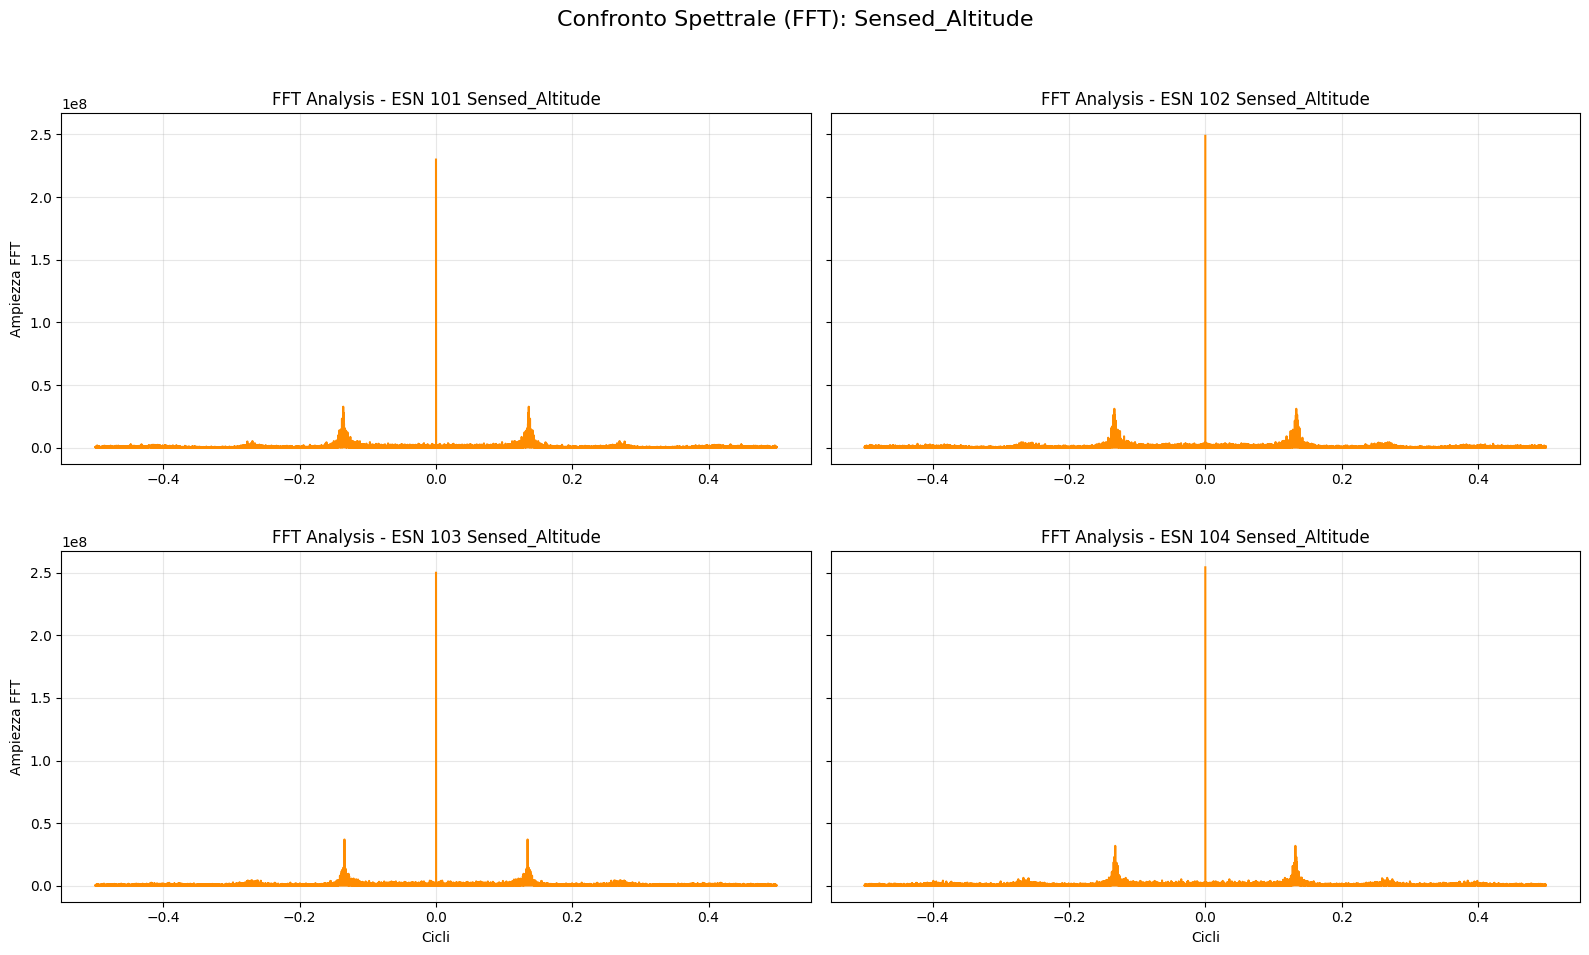

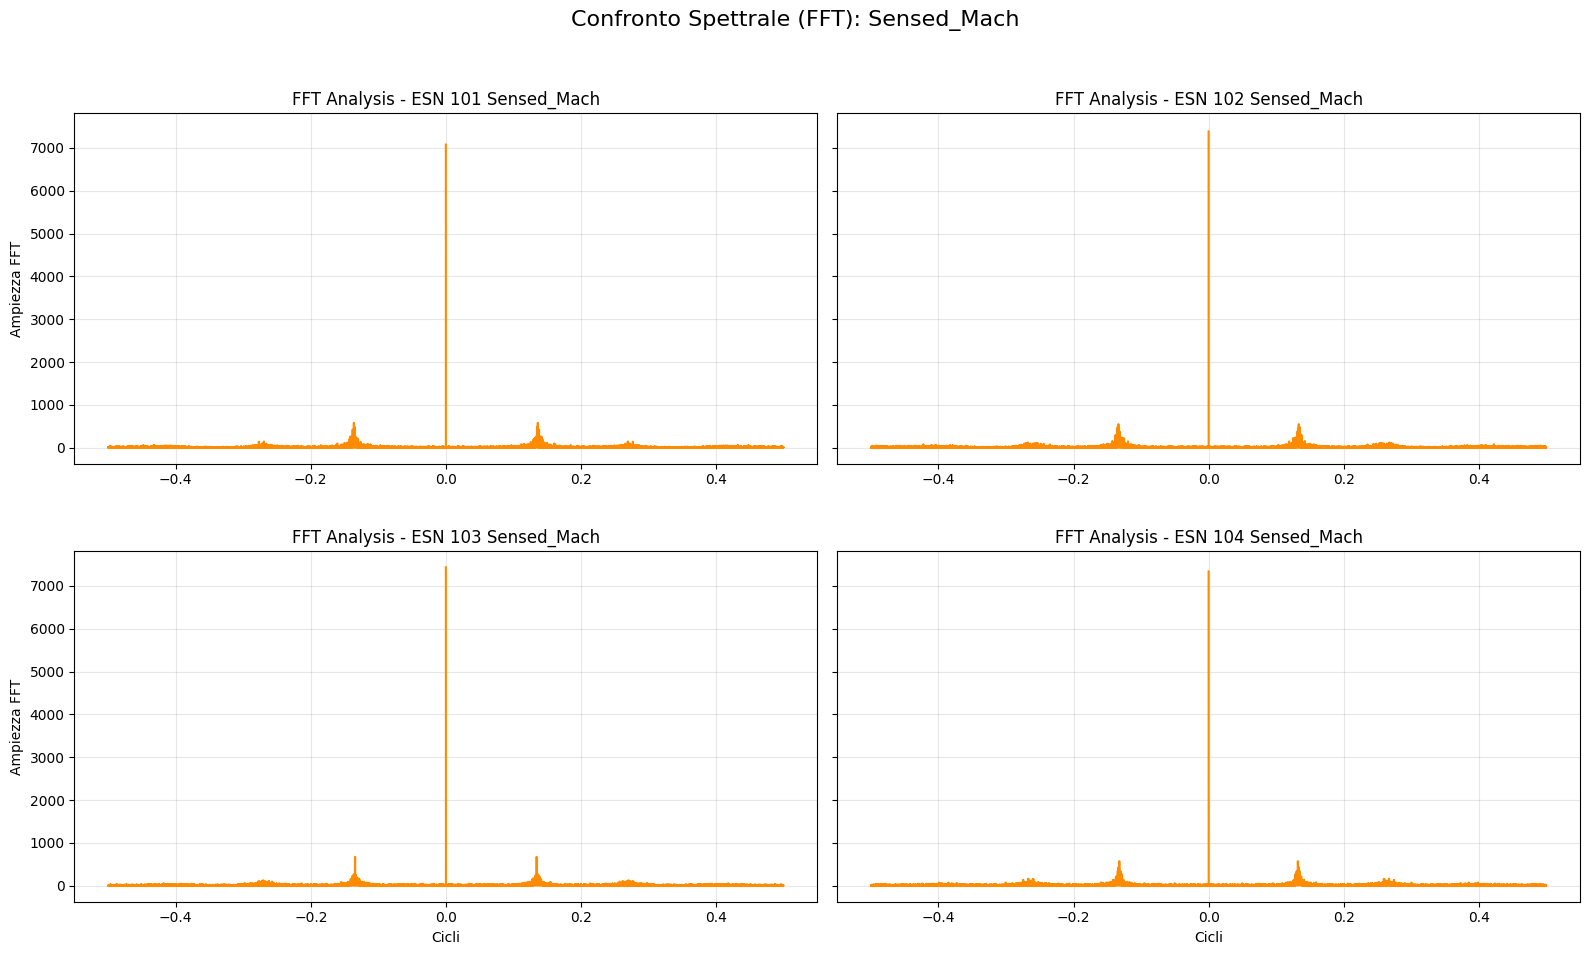

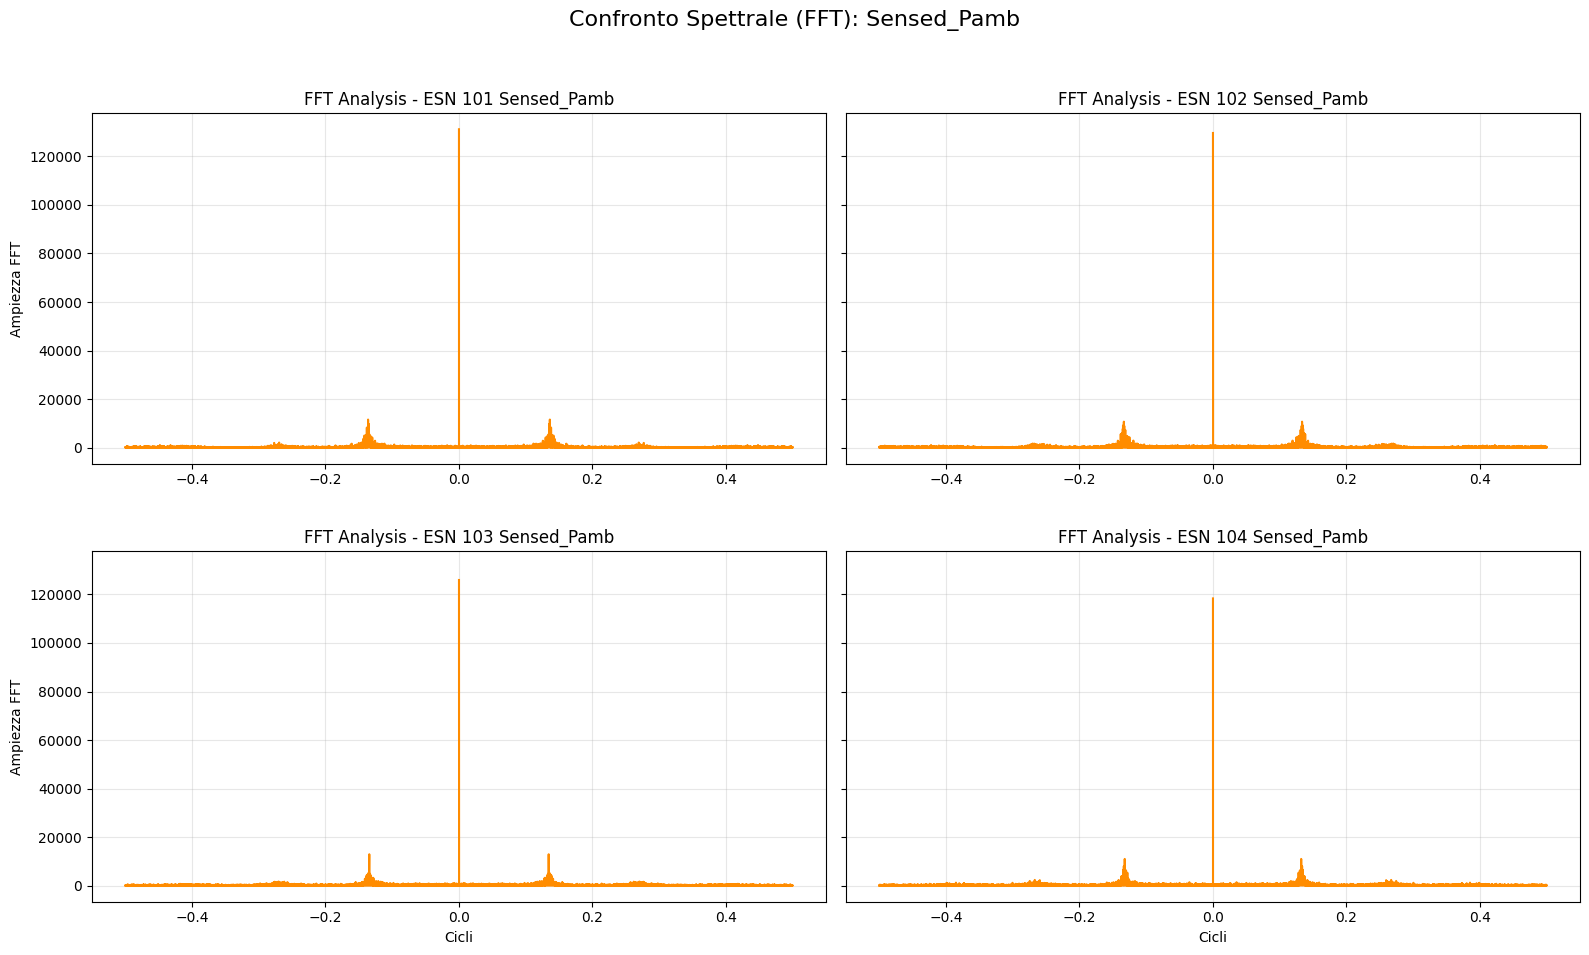

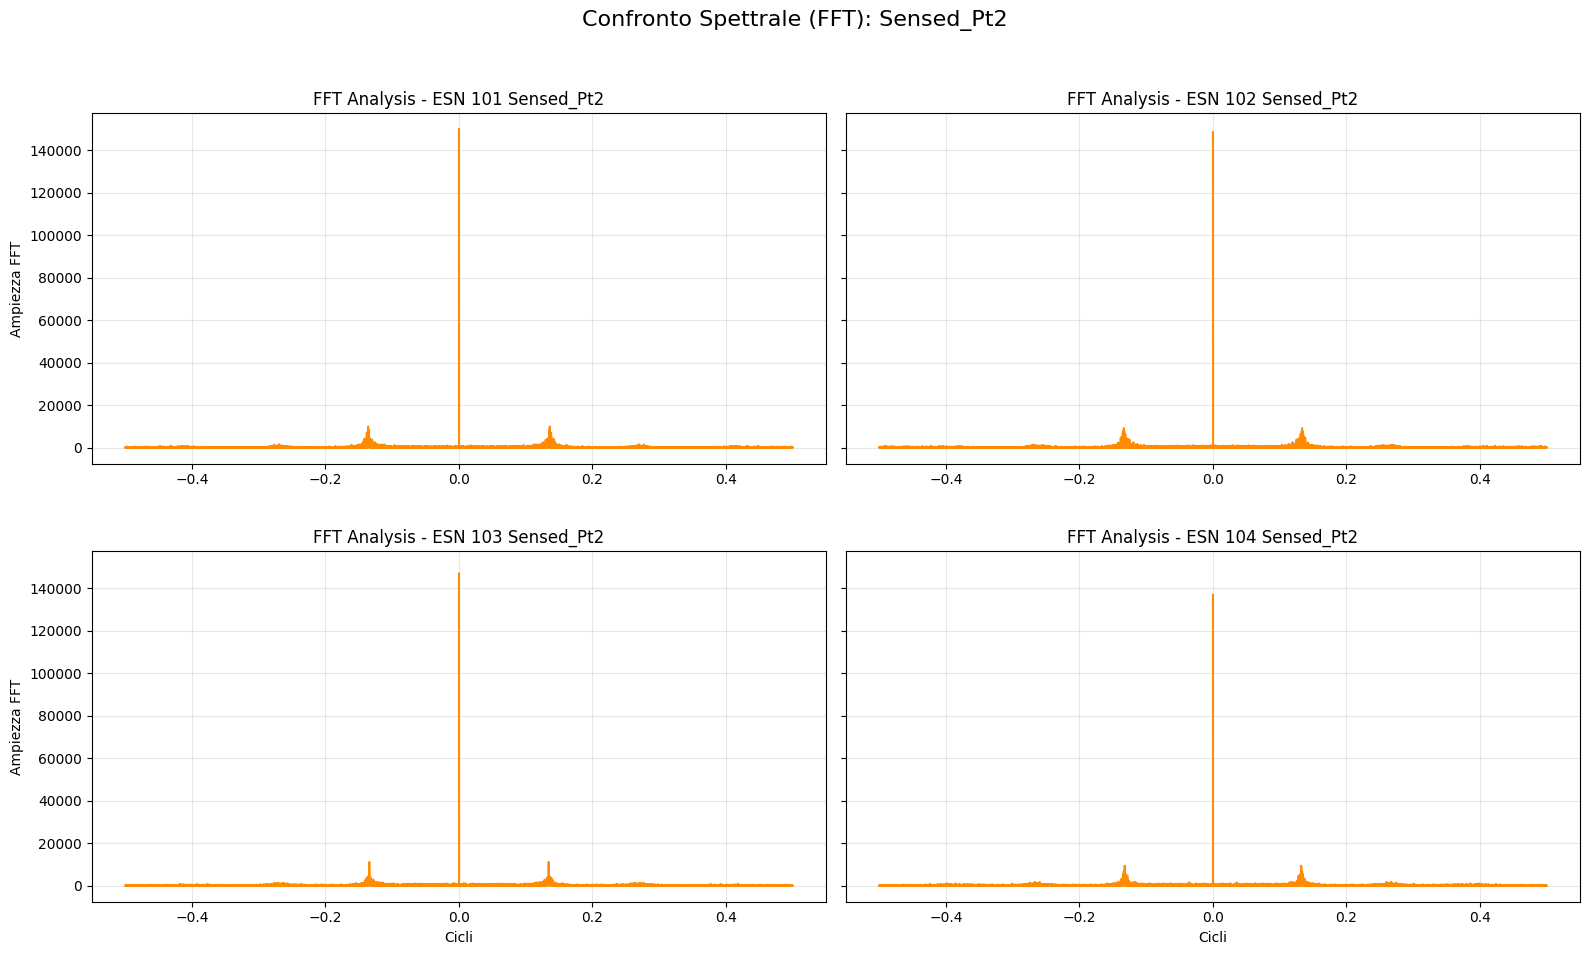

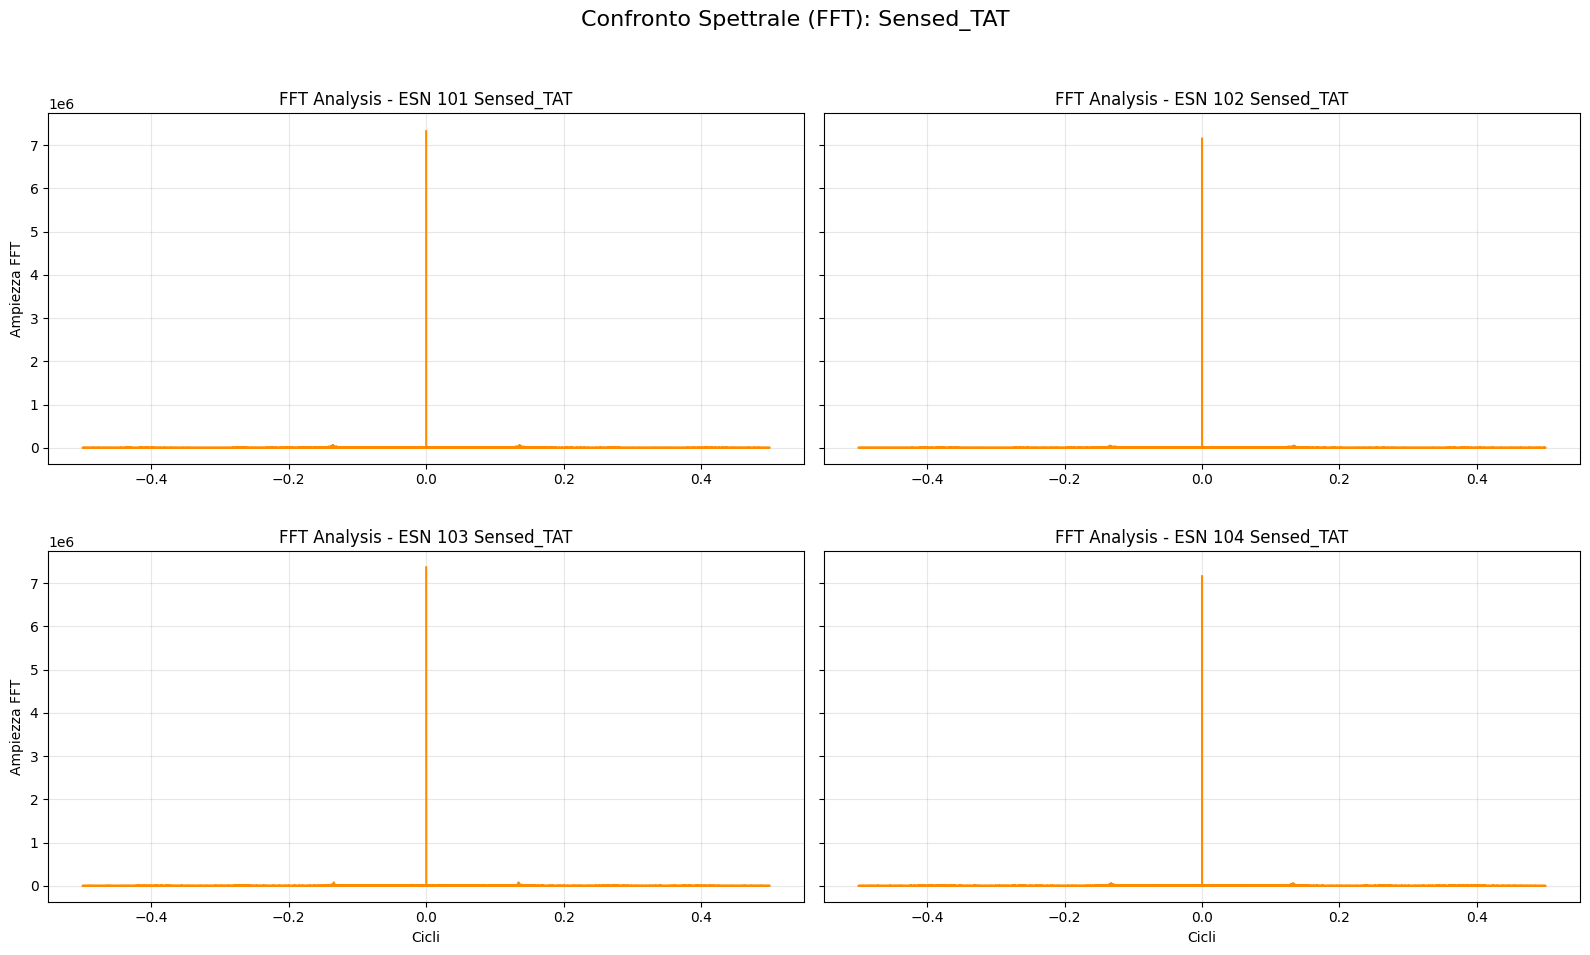

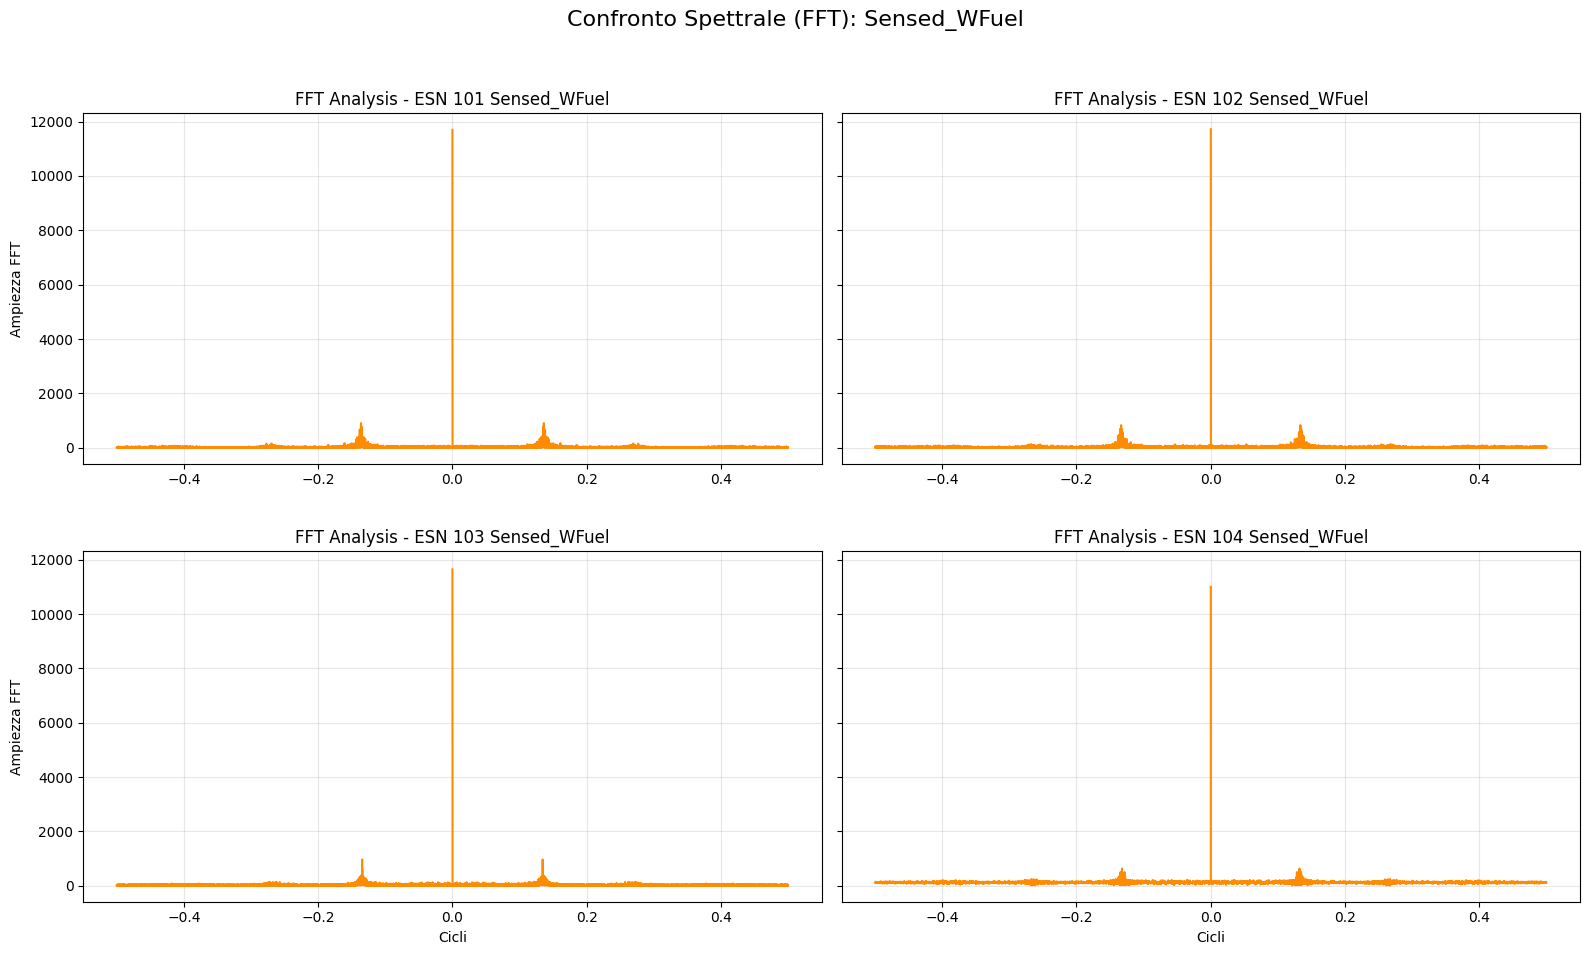

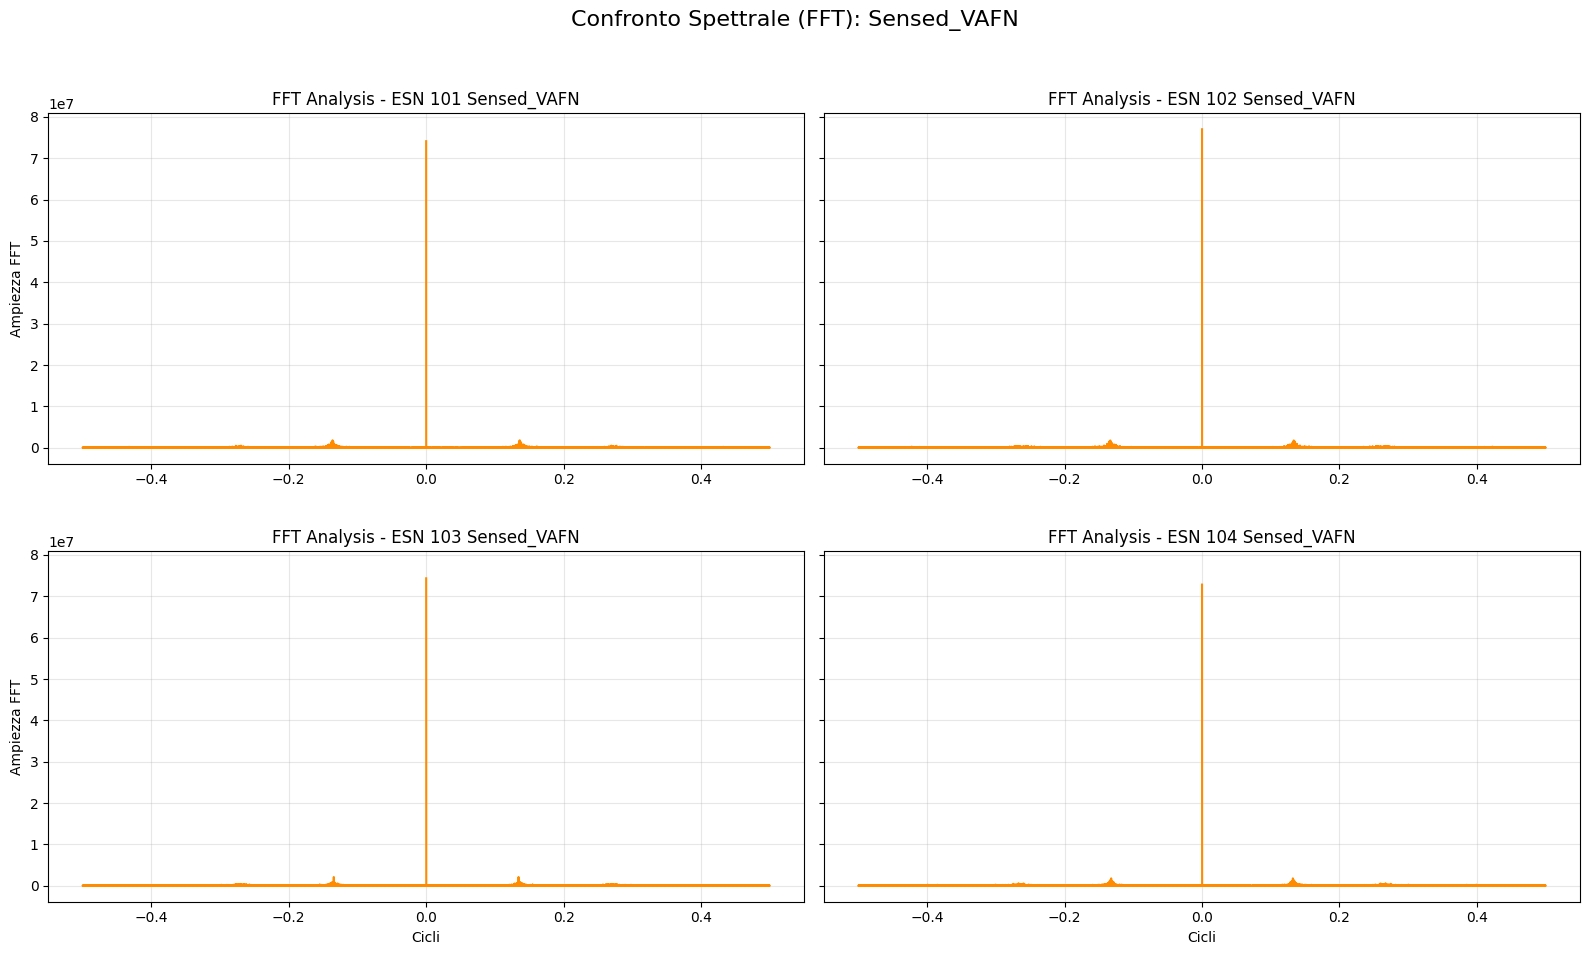

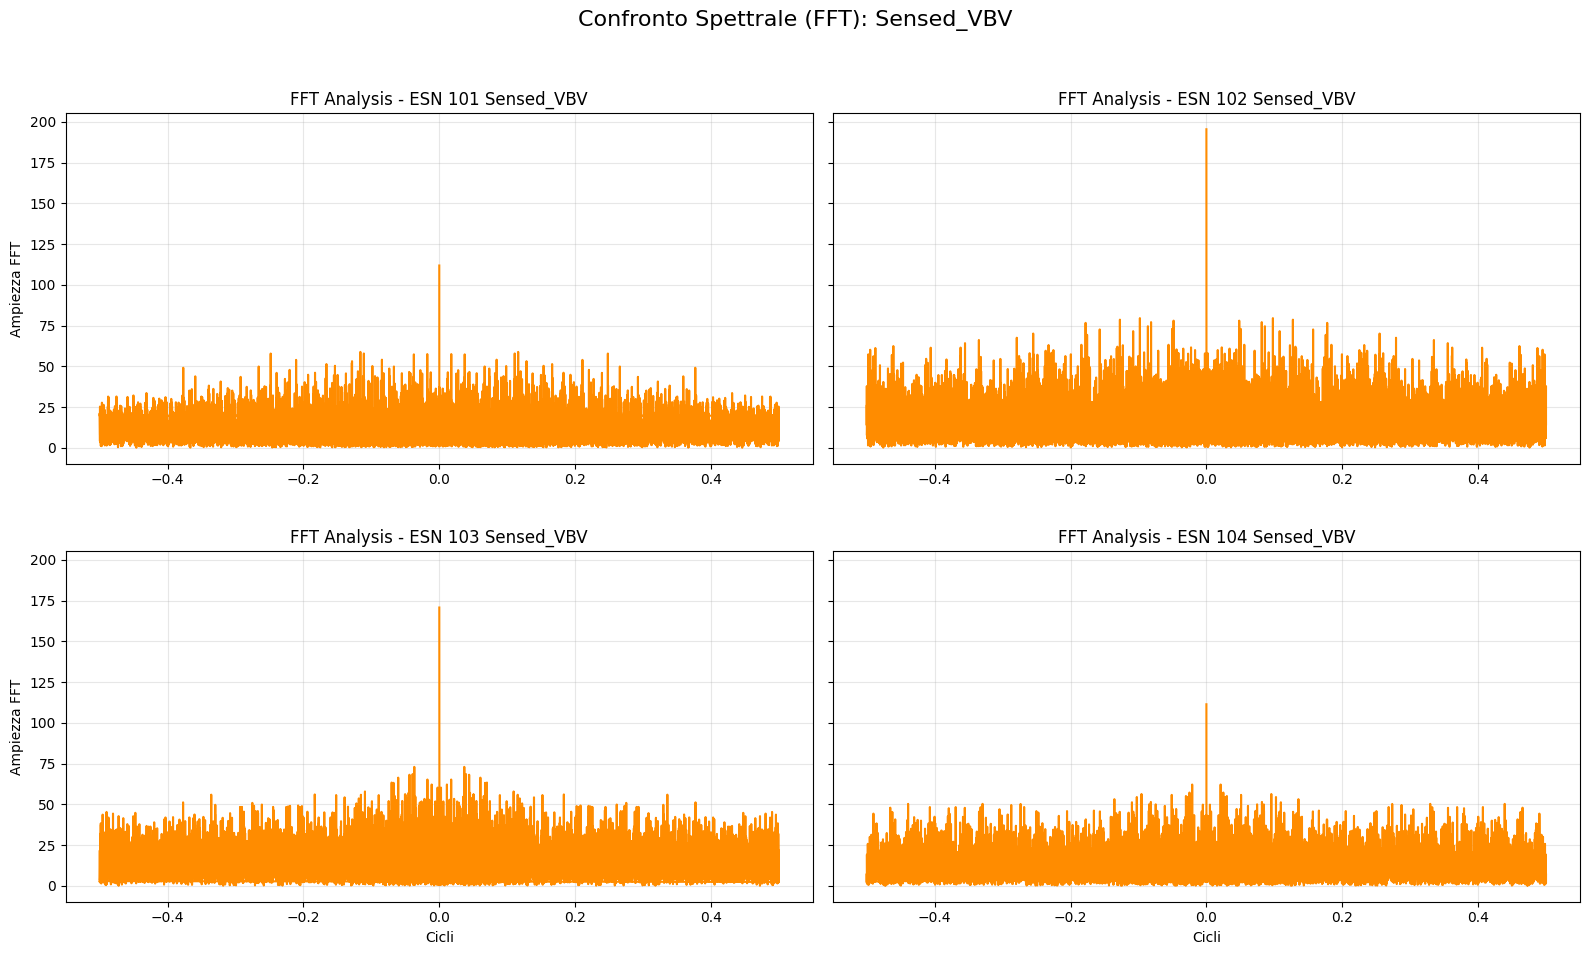

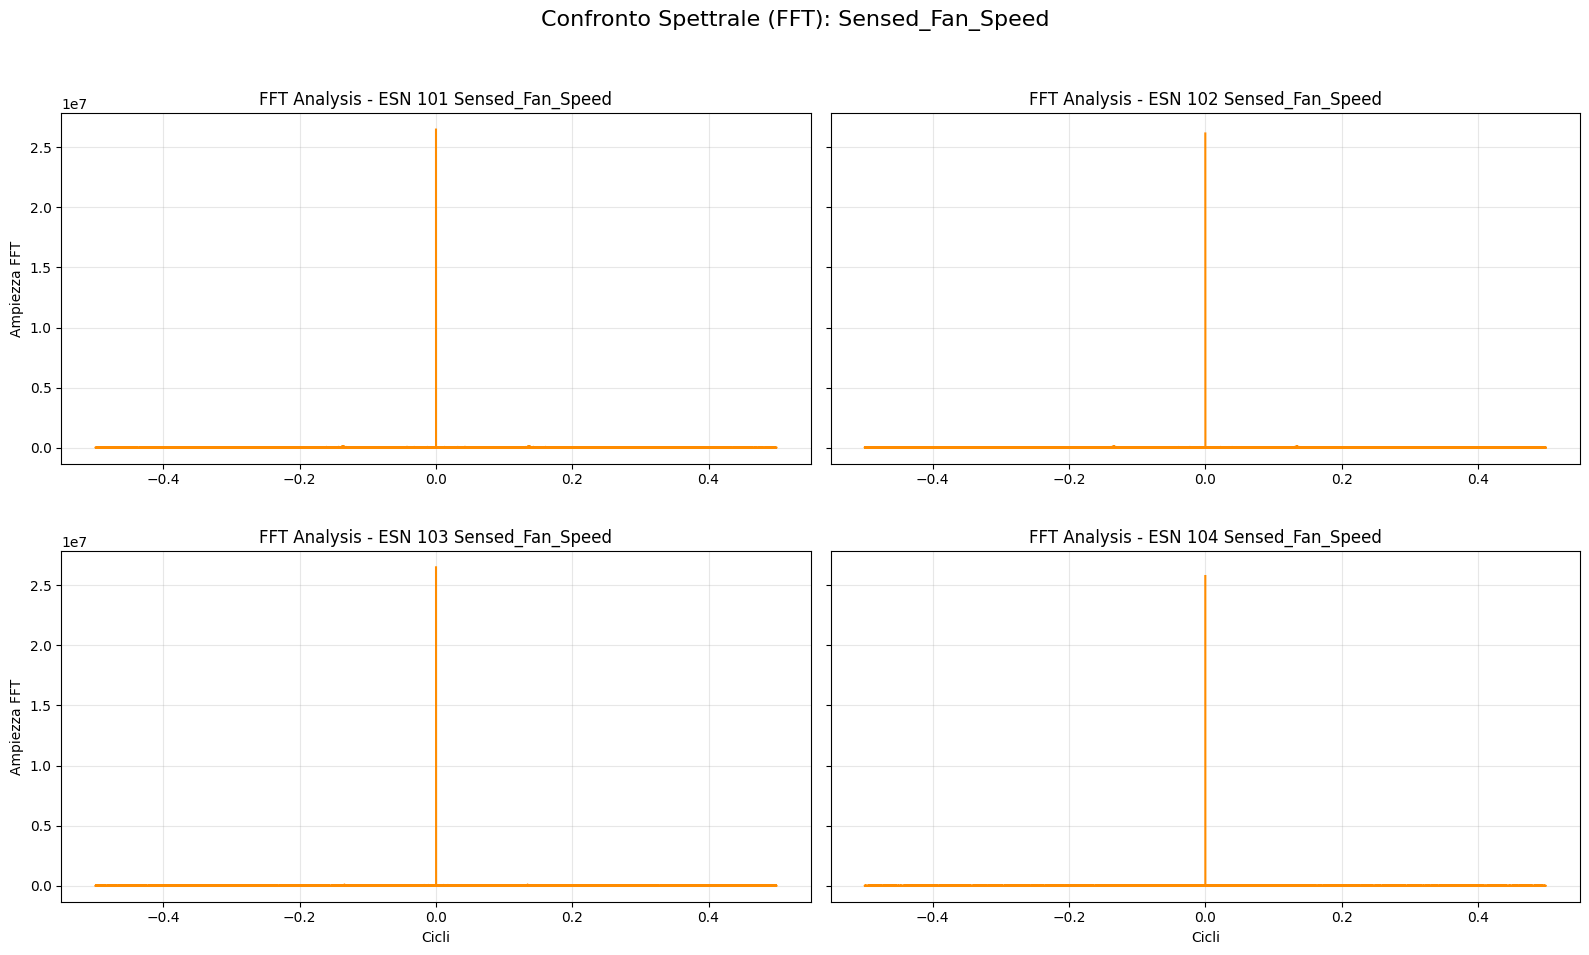

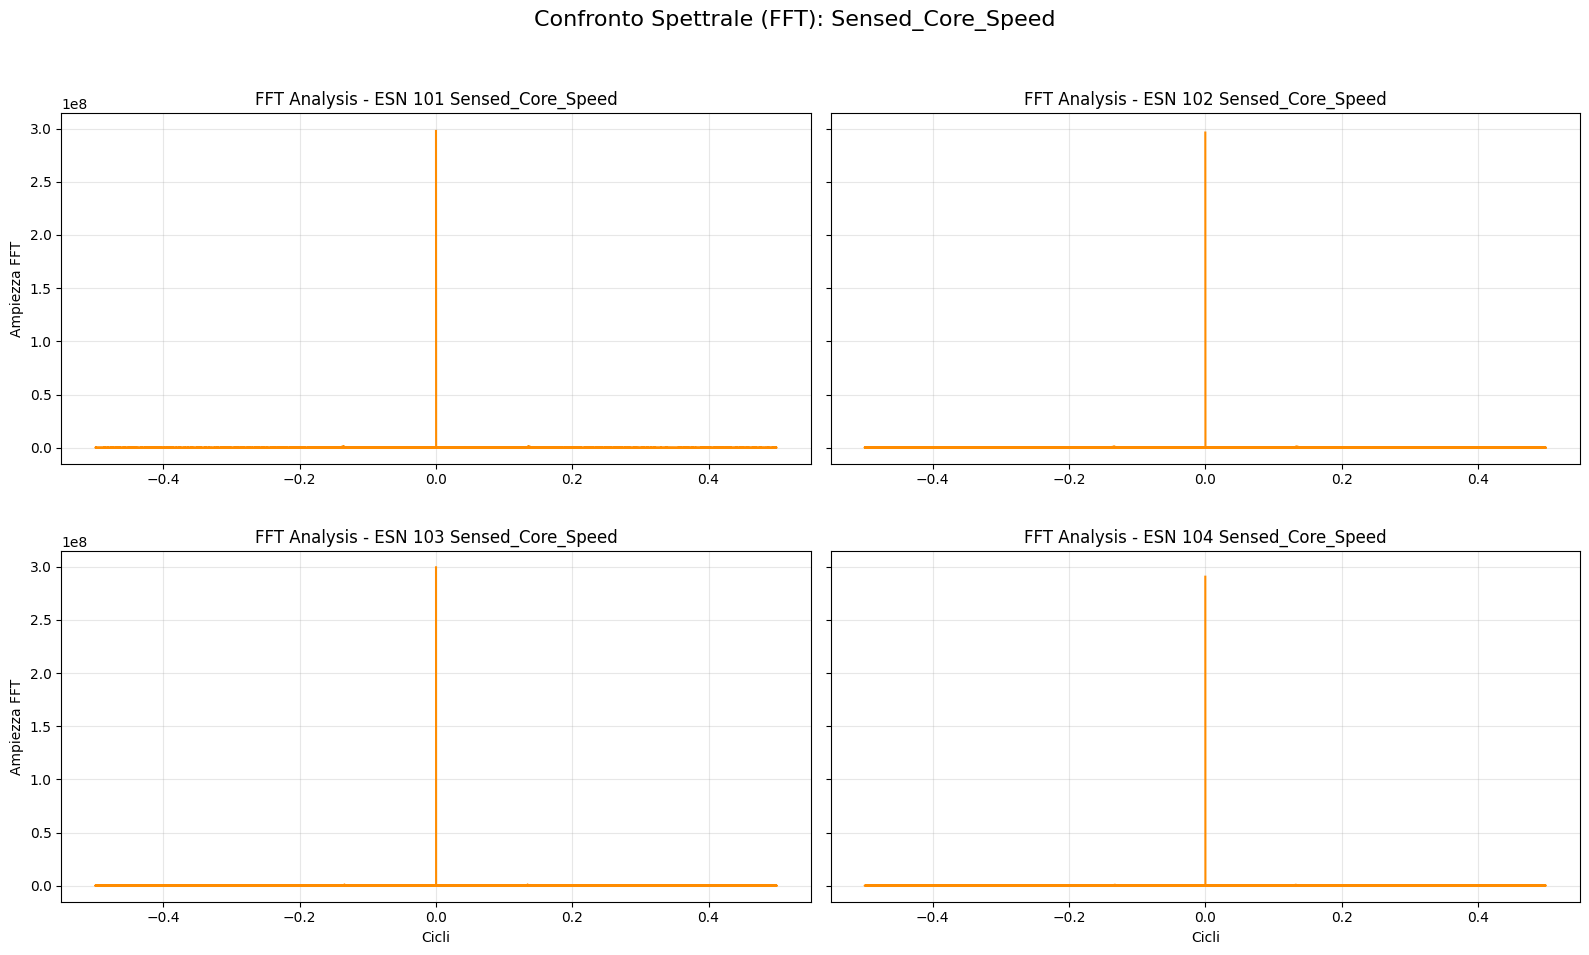

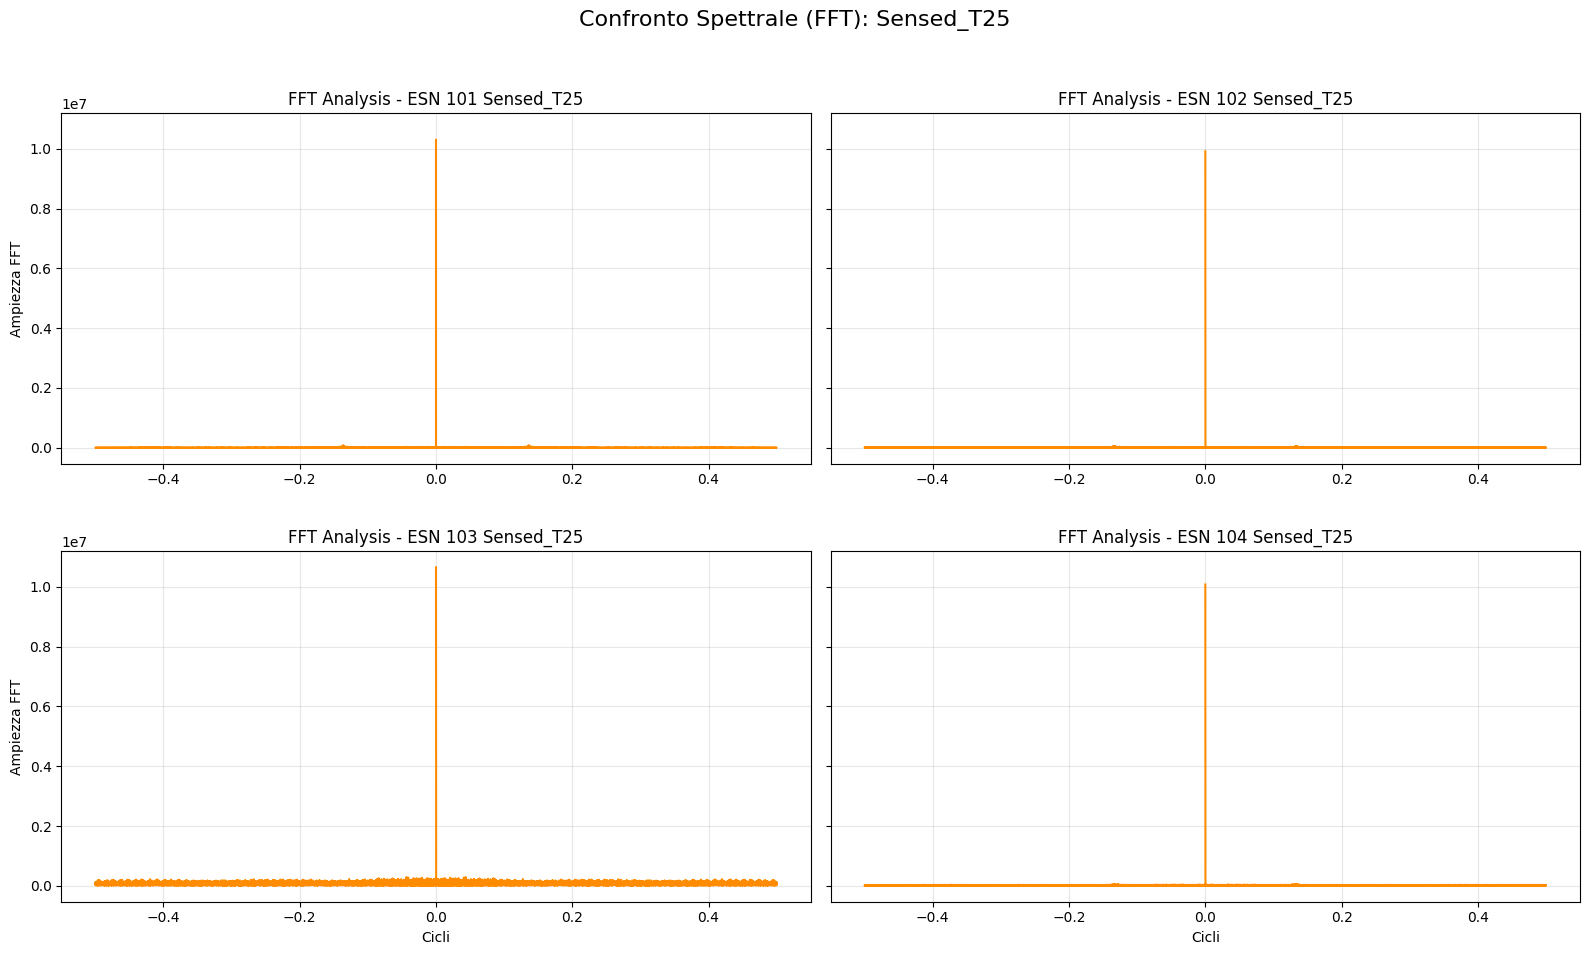

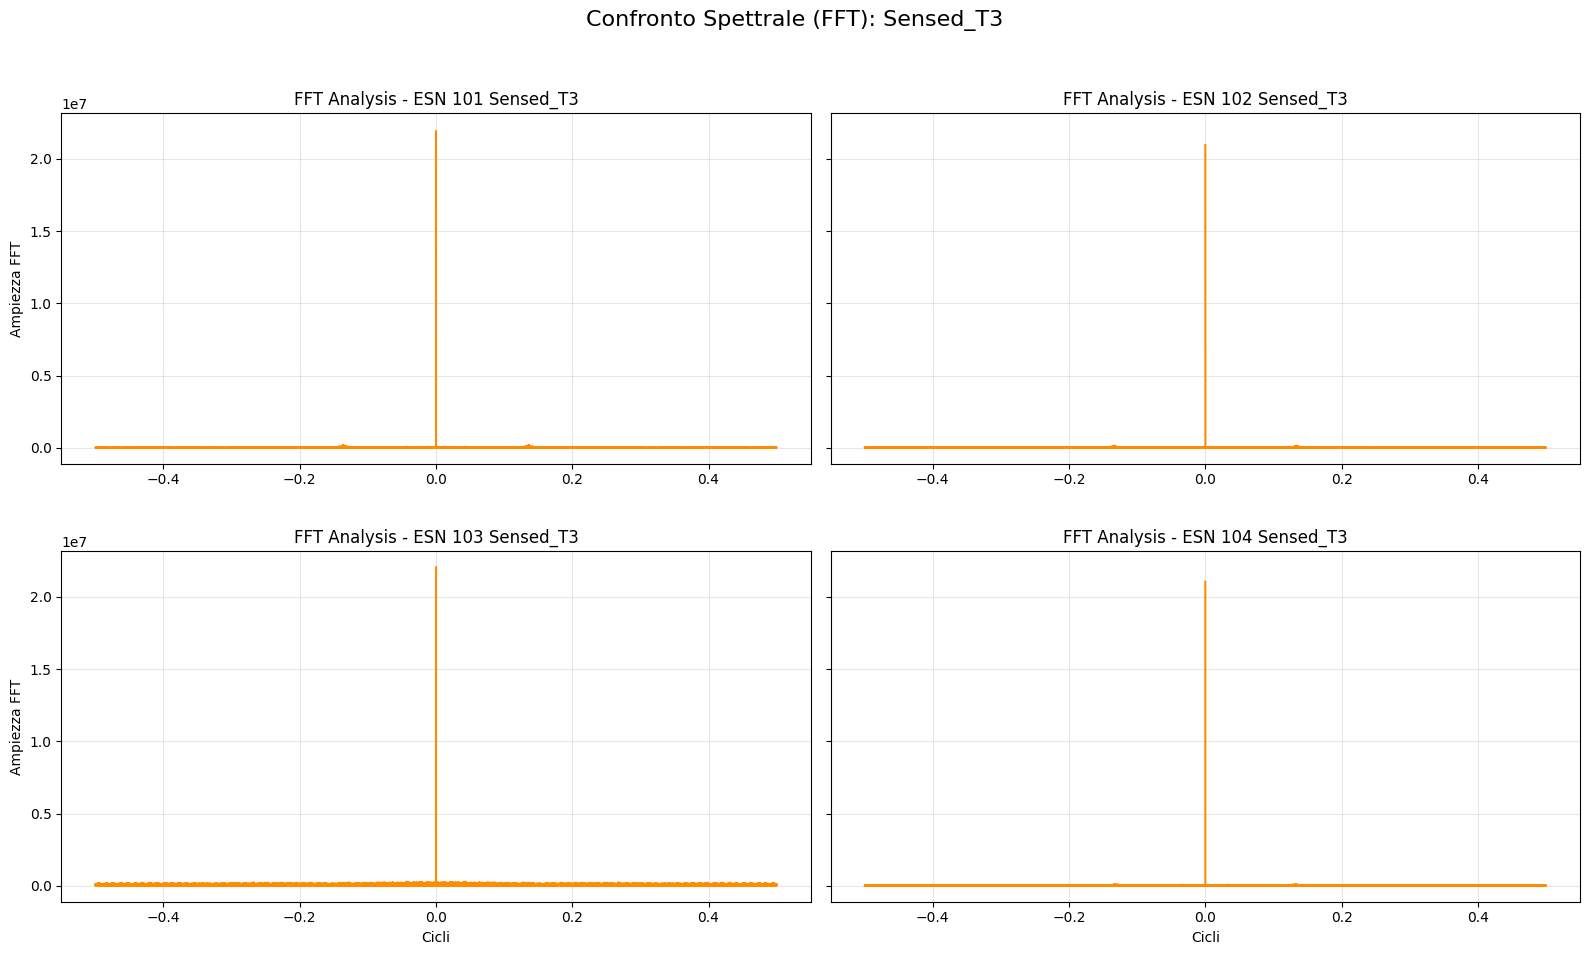

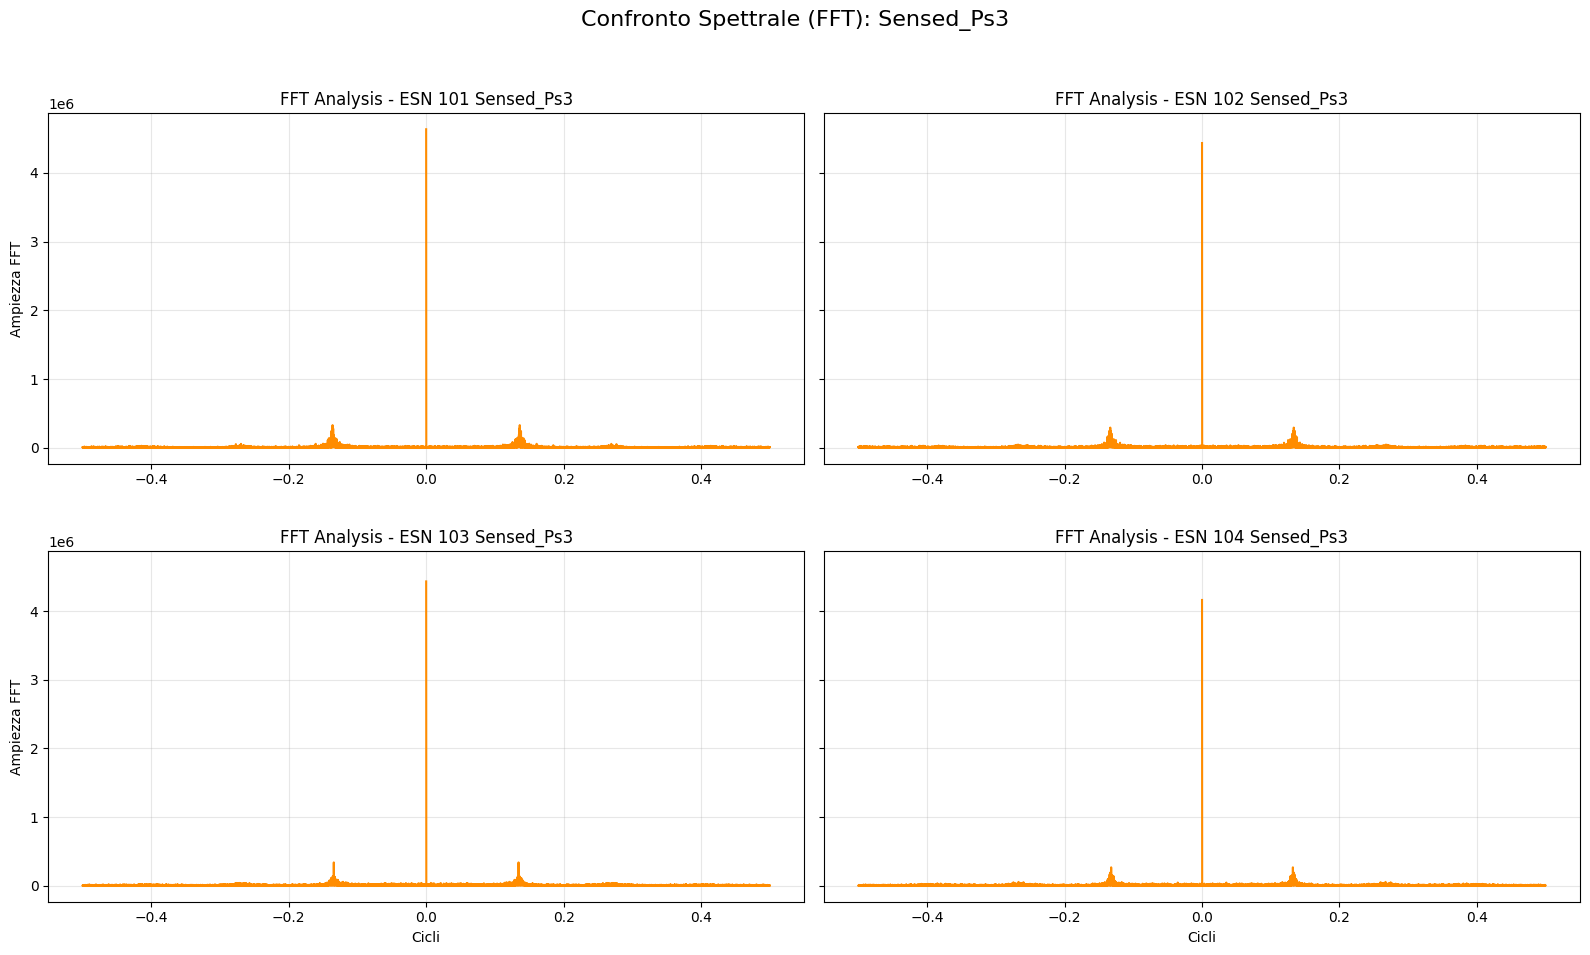

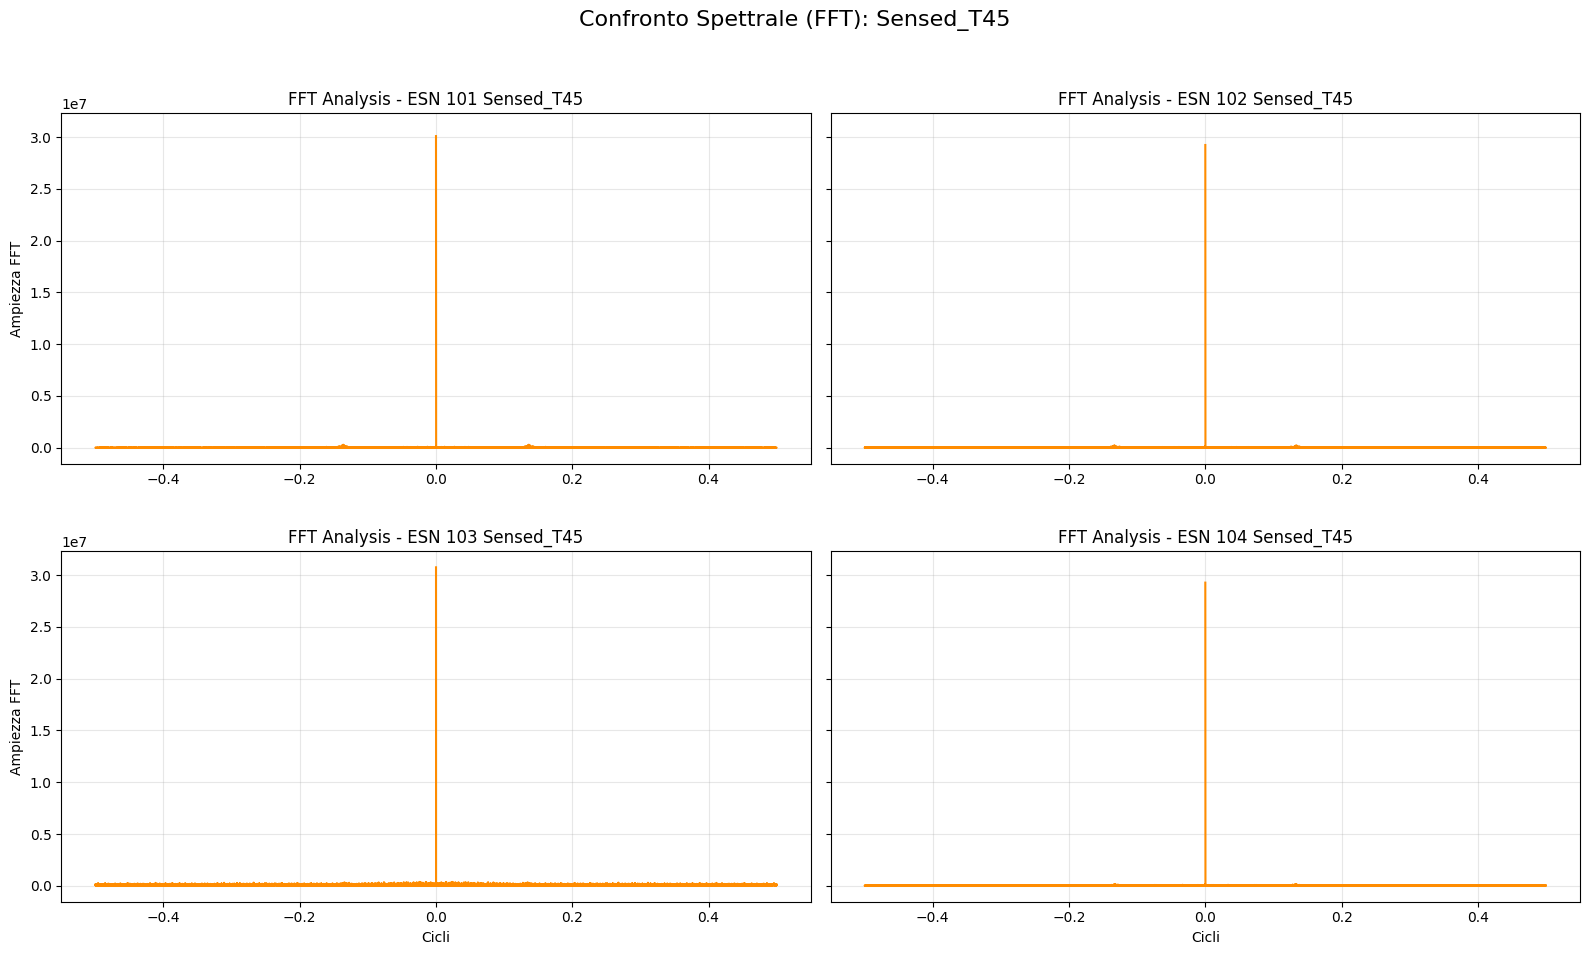

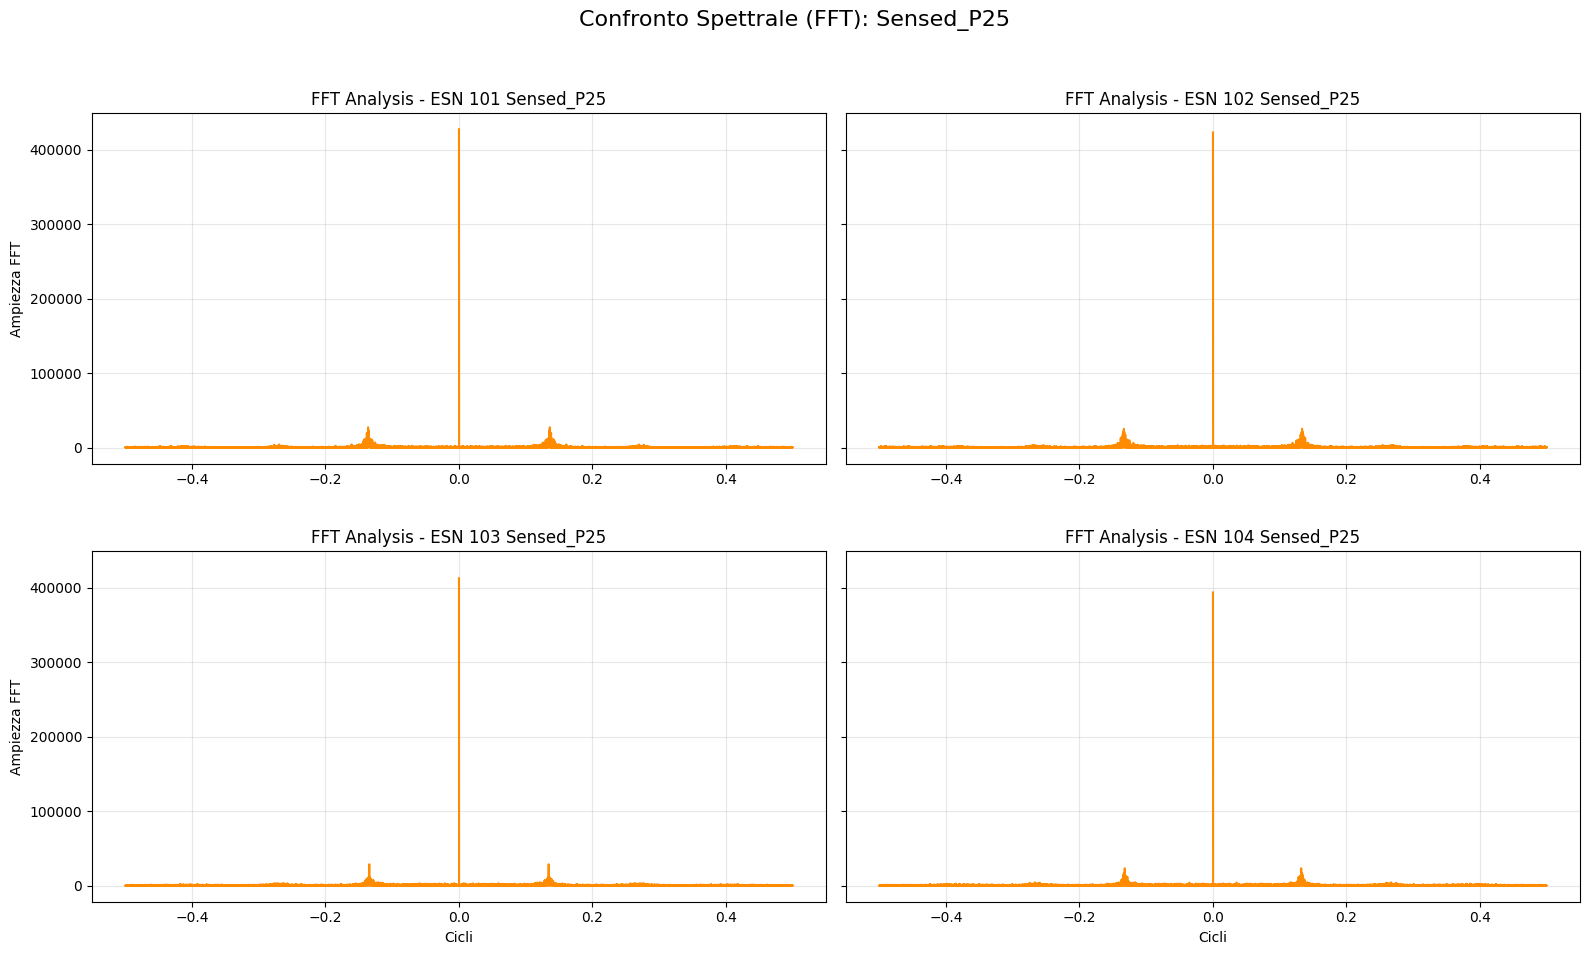

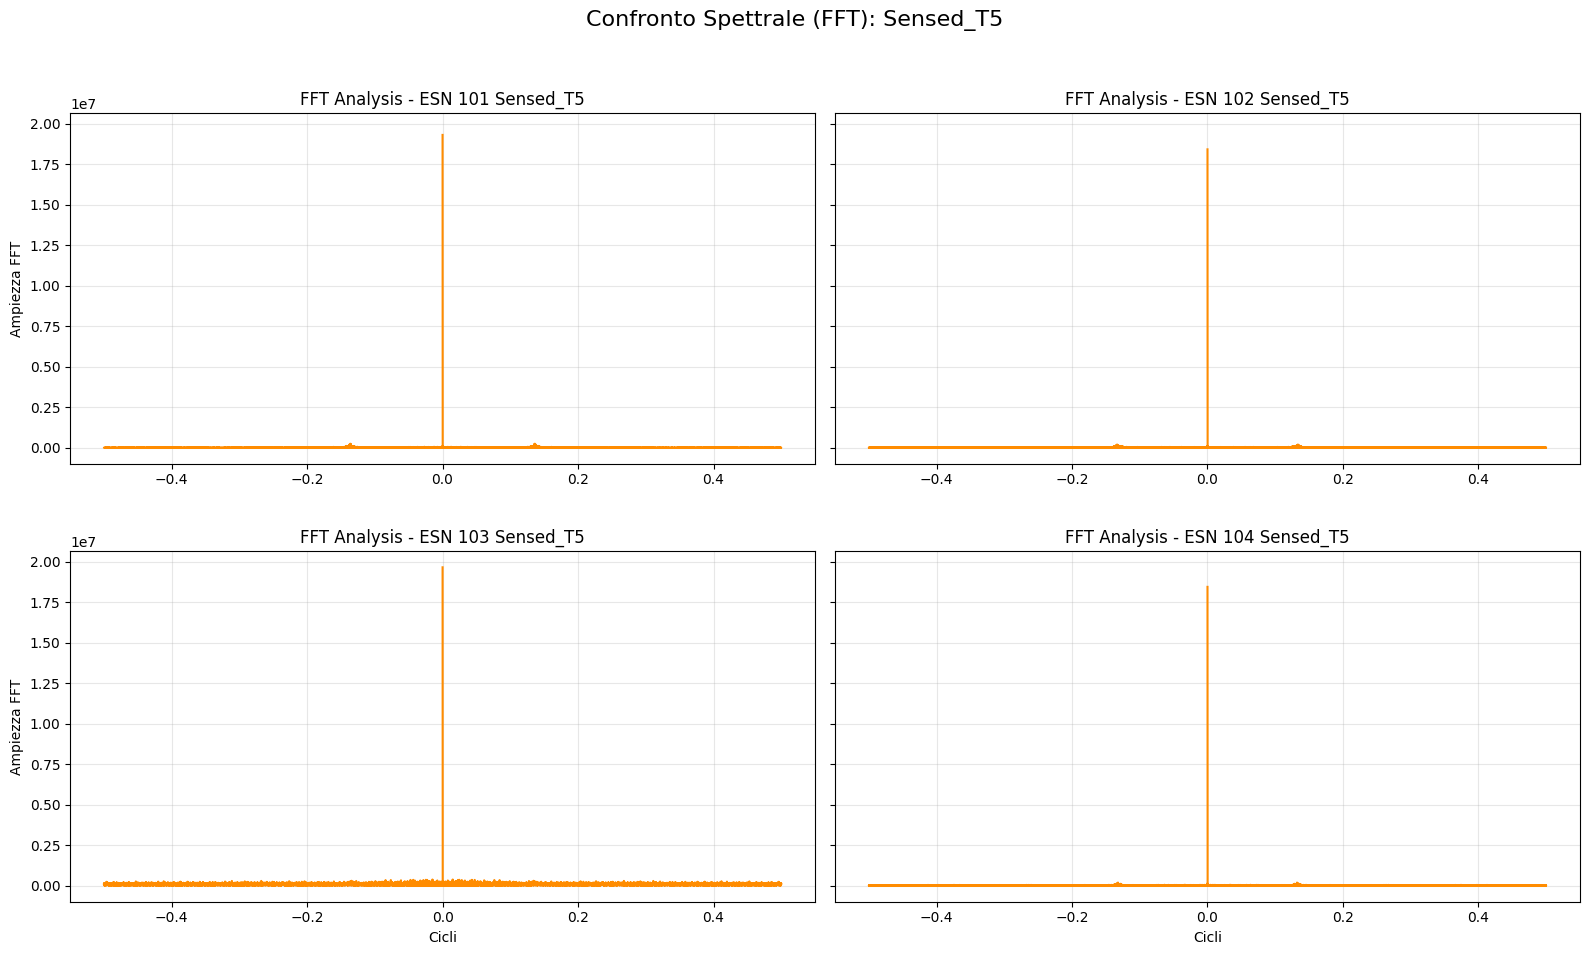

In [12]:
for s in generals.SENSORS.iter():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()
    for i, esn_id in enumerate(train['ESN'].unique()):
        ax = axes[i]

        df = train.loc[train['ESN'] == int(esn_id), [s]].copy()
        xf, yf = generals.my_fft(df[s].to_numpy(), fs=1.0)

        ax.plot(xf, np.abs(yf), color='darkorange')

        ax.set_title(f'FFT Analysis - ESN {esn_id} {s}')
        ax.grid(True, alpha=0.3)
        if i >= 2: ax.set_xlabel('Cicli')
        if i % 2 == 0: ax.set_ylabel('Ampiezza FFT')

    fig.suptitle(f'Confronto Spettrale (FFT): {s}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)
    plt.show()

# FFT groupby snapshot e ESN

In [13]:
check_init()

esn = 104
for sensor in generals.SENSORS.iter():
    N = 20000
    df = generals.filter(train, "ESN", esn).interpolate().fillna(0).copy() 
    y = []
    for s in range(1,9):
        y.append(df.loc[df["Snapshot"] == s, [sensor]].to_numpy())
    # in pratica abbiamo creato una lista di liste, ogni riga di y corrisponde
    # a tutti i valori corrispondenti ad un valore di snapshot

    fs = 1.0
    y_detrended = []
    yf = []
    freqs = []
    half_n = []
    freqs_pos = []
    fft_mag = []

    for s in range(0,8):
        T_tot = len(y[s])
        y_detrended.append(y[s] - np.mean(y[s]))

        yf.append(np.fft.fft(y_detrended[s]))
        freqs.append(np.fft.fftfreq(len(y[s]), d=1/fs))

        half_n.append(len(y[s]) // 2)
        freqs_pos.append(freqs[s][:half_n[s]])
        fft_mag.append(np.abs(yf[s])[:half_n[s]] * (2 / len(y[s])))

    fig, axs = plt.subplots(4,2, figsize=(20,30), sharey=True)
    for i in range(0,8):
        col = i//4
        row = i%4
        axs[row,col].plot(freqs_pos[i], fft_mag[i], color='darkblue', linewidth=1)
        axs[row,col].set_xlabel('Frequenza')
        axs[row,col].set_ylabel('Ampiezza')
        axs[row,col].grid(True, alpha=0.3)
        axs[row,col].set_title(f'Snapshot {i+1}')
        axs[row,col].set_xlim(0, 0.5) 

        y_max = np.max(fft_mag[i])

    plt.tight_layout()
    plt.title(f"FFT sul sensore {sensor} - ESN {esn}")
    path = generals.plot_path("FFT-SENSORS", esn, filename=f"FFT-{esn}-{sensor}.png")
    plt.savefig(path)
    plt.close()